# Imports & Setup

In [1]:
import os
import copy
import json
import math
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, models, transforms, utils
from torch.utils.data import DataLoader, Dataset, random_split, Subset

In [4]:
import pennylane as qml
import pennylane.qnn as qnn
from pennylane import numpy as pnp

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
from paths_setup import TRAIN_DIR, TEST_DIR, MODEL_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")

if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")

if not MODEL_DIR.exists():
    raise FileNotFoundError(f"MODEL_DIR not found: {MODEL_DIR}")

In [7]:
VIEW_CLASS       = sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir())
view_class_test  = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir())

if VIEW_CLASS != view_class_test:
    raise ValueError("TRAIN_DIR and TEST_DIR must contain the same classes!")

print(f"VIEW_CLASS: {VIEW_CLASS}")

VIEW_CLASS: ['02', '06', '08', '12', '13', '14', '15', '16', '18', '21', '22', '23', '27', '30']


In [8]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_WORKERS = 8
SEED        = 42
VAL_SPLIT   = 0.2

In [9]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Data Exploration

In [10]:
EXCLUDED_FILES = set()
excluded_files_path = MODEL_DIR / "excluded_files.json"

In [11]:
def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.add(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [12]:
EXCLUDED_FILES.clear()

if excluded_files_path.exists():
    EXCLUDED_FILES = set(json.loads(excluded_files_path.read_text(encoding="utf-8")))
    print(f"Loaded excluded files from: {excluded_files_path}")
else:
    verify_image_dimensions(TRAIN_DIR, IMG_SIZE)
    verify_image_dimensions(TEST_DIR,  IMG_SIZE)

    excluded_files_path.write_text(json.dumps(sorted(EXCLUDED_FILES), indent=2), encoding="utf-8")
    print(f"Saved excluded files to: {excluded_files_path}")

print(f"Files to exclude: {EXCLUDED_FILES}")

Loaded excluded files from: /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/ViewClassification/VC_Default/Models/excluded_files.json
Files to exclude: {'__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png', '__Amy__DicomIMG_ID_69214103__20200810140438__1.png'}


# Data Preprocessing

## Data Transforms

In [13]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [14]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [15]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [16]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size   = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [17]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size:   ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size:       ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:    140115
Validation set size:  35029
Test set size:        35199


## Class Weights

In [18]:
num_classes = len(base_dataset.classes)

In [19]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets, minlength=num_classes)
total_samples = len(train_targets)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [20]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


In [21]:
class_mapping_path = MODEL_DIR / "class_mapping.json"

if class_mapping_path.exists():
    with open(class_mapping_path, "r", encoding="utf-8") as f:
        class_mapping = json.load(f)
    print(f"Loaded class mapping: {class_mapping_path}")
else:
    class_mapping = base_dataset.classes
    with open(class_mapping_path, "w", encoding="utf-8") as f:
        json.dump(class_mapping, f, indent=2)
    print(f"Saved class mapping: {class_mapping_path}")

print(class_mapping)

Loaded class mapping: /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/ViewClassification/VC_Default/Models/class_mapping.json
['02', '06', '08', '12', '13', '14', '15', '16', '18', '21', '22', '23', '27', '30']


## Data Loaders

In [22]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)

# Noise Utilities

In [23]:
N_QUBITS   = 4
N_LAYERS   = 2
NUM_EPOCHS = 15

In [24]:
# Noise probability for 1-qubit gates (0.5%) and for 2-qubit gates (2.0%)
P_1Q = 0.005
P_2Q = 0.02

In [25]:
NOISE_TYPE = "Depolarizing"

In [26]:
NOISE_SUFFIX = f"_{NOISE_TYPE}" if NOISE_TYPE else "_Clean"
NOISE_CHANNELS = {"Depolarizing": qml.DepolarizingChannel}

In [27]:
def build_noise_model(noise_type, p_1q=P_1Q, p_2q=P_2Q):
    channel = NOISE_CHANNELS[noise_type]

    @qml.BooleanFn
    def is_1q_gate(op, **metadata):
        return getattr(op, "num_wires", None) == 1 and not isinstance(op, qml.operation.Channel)

    @qml.BooleanFn
    def is_2q_gate(op, **metadata):
        return getattr(op, "num_wires", None) == 2 and not isinstance(op, qml.operation.Channel)

    # 1-qubit gate
    noise_1q = qml.noise.partial_wires(channel, p_1q)

    # 2-qubit gate: apply independently to both participating wires
    def noise_2q(op, **metadata):
        for w in op.wires:
            channel(p_2q, wires=w)

    return qml.NoiseModel({is_1q_gate: noise_1q,
                           is_2q_gate: noise_2q})

In [28]:
if NOISE_TYPE:
    test_nm = build_noise_model(NOISE_TYPE)
    print(f"Noise utilities loaded! Test Noise Model ({NOISE_TYPE}): {test_nm}")

Noise utilities loaded! Test Noise Model (Depolarizing): NoiseModel({
    BooleanFn(is_1q_gate): DepolarizingChannel(p=0.005)
    BooleanFn(is_2q_gate): noise_2q
})


In [29]:
def make_device_and_noise(noise_type=None, p_1q=P_1Q, p_2q=P_2Q):
    if noise_type is None:
        return qml.device("default.qubit", wires=N_QUBITS), None

    dev = qml.device("default.mixed", wires=N_QUBITS)
    nm = build_noise_model(noise_type, p_1q=p_1q, p_2q=p_2q)
    return dev, nm

In [30]:
def wrap_with_noise(qnode, noise_model):
    if noise_model is None:
        return qnode
        
    return qml.add_noise(qnode, noise_model, level="device")

# Utility Functions

In [31]:
def train_model(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_val_acc = 0.0
    best_train_acc = 0.0
    
    print(f"Starting training {model_name} model for {num_epochs} epochs...")
    
    total_start = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                if phase == 'train':
                    optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_train_acc:
                    best_train_acc = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        epoch_elapsed = time.time() - epoch_start
        history['epoch_times'].append(epoch_elapsed)
        print(f'Epoch Time: {epoch_elapsed:.1f}s')
        print()
    
    total_elapsed = time.time() - total_start
    history['total_time'] = total_elapsed
    
    print(f'\nBest Val Acc:   {best_val_acc:.4f}')
    print(f'Best Train Acc: {best_train_acc:.4f}')
    print(f'Total Training Time: {total_elapsed:.1f}s ({total_elapsed/60:.1f}m)')
    print(f'Average Epoch Time:  {np.mean(history["epoch_times"]):.1f}s')
    model.load_state_dict(best_model_wts)
    return model, history

In [32]:
def plot_learning_curves(history):
    acc      = history['train_acc']
    val_acc  = history['val_acc']
    loss     = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch  = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)
    
    plt.figure(figsize=(14, 6))

    # Plot Accuracy

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    plt.scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    
    plt.legend(loc='lower right')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Plot Loss

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    plt.scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [33]:
def evaluate_model(model, dataloader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy_score(y_true, y_pred)

In [34]:
def save_model(trained_model, model_path, model_name):
    torch.save(trained_model.state_dict(), MODEL_DIR / model_path)
    print(f"Saved model weights for {model_name}: {model_path}")

# NISQ Testing - Hybrid Classical-Quantum Models

## QNN (Hybrid)

### Define Model

In [35]:
model_name_qnn = "HybridQNN"
(MODEL_DIR / model_name_qnn).mkdir(parents=True, exist_ok=True)
model_path_qnn = f"{model_name_qnn}/{model_name_qnn}{NOISE_SUFFIX}.pth"

In [36]:
def make_qlayer_qnn():
    dev, nm = make_device_and_noise()

    @qml.qnode(dev, interface='torch')
    def quantum_circuit_qnn(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

    quantum_circuit_qnn = wrap_with_noise(quantum_circuit_qnn, nm)
    
    weight_shapes_qnn = {"weights": (N_LAYERS, N_QUBITS, 3)}
    
    qlayer_qnn = qnn.TorchLayer(quantum_circuit_qnn, weight_shapes_qnn)
    
    return qlayer_qnn

In [37]:
class HybridQNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.fc1 = nn.Linear(32, N_QUBITS)
        self.qlayer = make_qlayer_qnn()
        self.fc2 = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [38]:
model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

criterion_qnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qnn = optim.Adam(model_qnn.parameters(), lr=1e-3)

In [39]:
trained_model_qnn, history_qnn = train_model(model_name=model_name_qnn,
                                             model=model_qnn,
                                             criterion=criterion_qnn,
                                             optimizer=optimizer_qnn,
                                             train_loader=train_loader,
                                             val_loader=val_loader,
                                             num_epochs=NUM_EPOCHS)

Starting training HybridQNN model for 15 epochs...

Epoch 1/15:
Train Loss: 2.5430 Acc: 0.0890
Val Loss: 2.2917 Acc: 0.1181
Epoch Time: 129.9s


Epoch 2/15:
Train Loss: 2.2269 Acc: 0.1587
Val Loss: 2.1762 Acc: 0.1702
Epoch Time: 134.5s


Epoch 3/15:
Train Loss: 2.0988 Acc: 0.2036
Val Loss: 1.9965 Acc: 0.2543
Epoch Time: 133.9s


Epoch 4/15:
Train Loss: 1.9309 Acc: 0.2703
Val Loss: 1.8762 Acc: 0.2954
Epoch Time: 132.7s


Epoch 5/15:
Train Loss: 1.8359 Acc: 0.3098
Val Loss: 1.7885 Acc: 0.3137
Epoch Time: 130.4s


Epoch 6/15:
Train Loss: 1.7673 Acc: 0.3255
Val Loss: 1.7134 Acc: 0.3562
Epoch Time: 132.7s


Epoch 7/15:
Train Loss: 1.6994 Acc: 0.3446
Val Loss: 1.6322 Acc: 0.3610
Epoch Time: 134.7s


Epoch 8/15:
Train Loss: 1.6259 Acc: 0.3661
Val Loss: 1.5860 Acc: 0.3898
Epoch Time: 130.0s


Epoch 9/15:
Train Loss: 1.5688 Acc: 0.3986
Val Loss: 1.5680 Acc: 0.4144
Epoch Time: 133.4s


Epoch 10/15:
Train Loss: 1.5120 Acc: 0.4337
Val Loss: 1.4913 Acc: 0.4432
Epoch Time: 132.0s


Epoch 11/15:
Trai

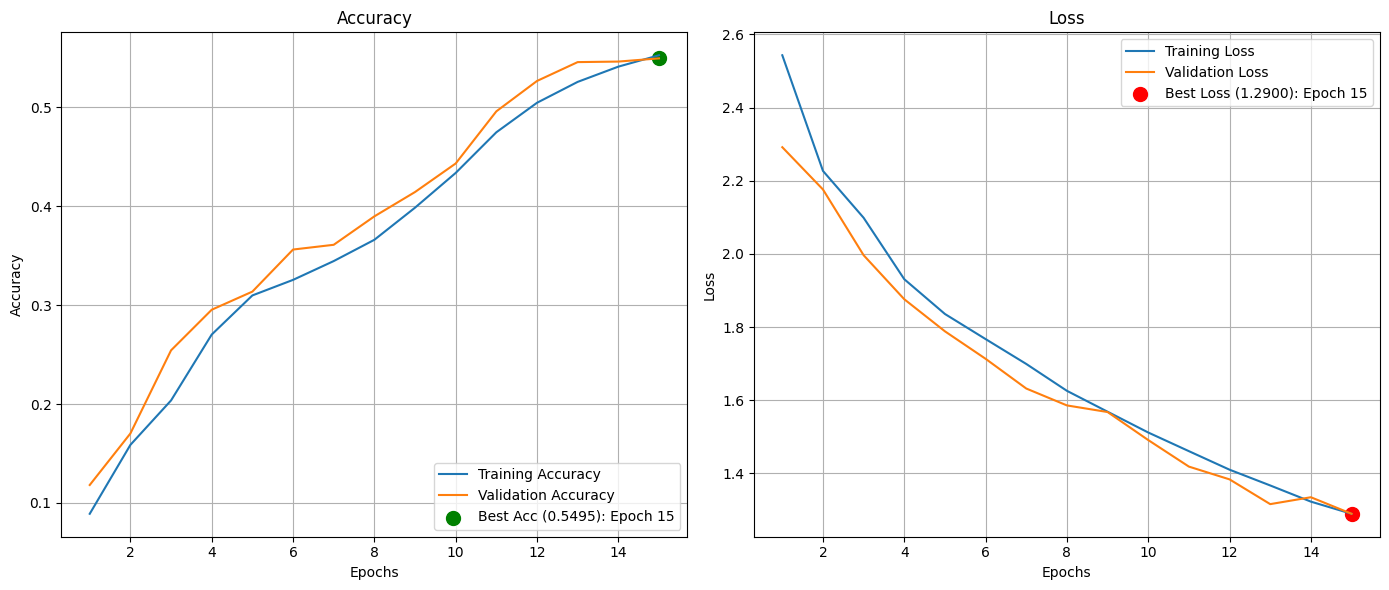

In [40]:
plot_learning_curves(history_qnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.60      0.59      0.60      4249
          06       0.00      0.00      0.00       401
          08       0.20      0.24      0.22      2748
          12       0.44      0.38      0.41      4633
          13       0.21      0.40      0.27      3429
          14       0.03      0.03      0.03      1139
          15       0.63      0.51      0.56      6421
          16       0.68      0.14      0.23      2061
          18       0.04      0.09      0.06      1058
          21       0.26      0.36      0.30      2899
          22       0.02      0.01      0.01       895
          23       0.35      0.18      0.24      2793
          27       0.42      0.24      0.31      1670
          30       0.34      0.47      0.39       803

    accuracy                           0.35     35199
   macro avg       0.30      0.26      0.26     35199
weighted avg       0.40      0.35      0.36     35

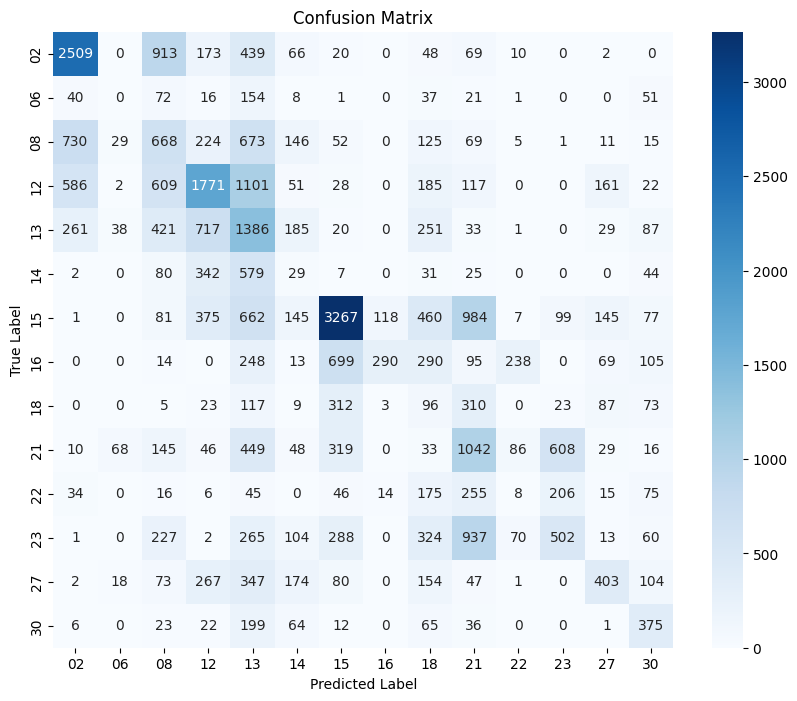

0.35074860081252307

In [41]:
evaluate_model(trained_model_qnn, test_loader, base_dataset.classes)

In [42]:
save_model(trained_model_qnn, model_path_qnn, model_name_qnn)

Saved model weights for HybridQNN: HybridQNN/HybridQNN_Depolarizing.pth


## Optimized QNN (Hybrid)

### Define Model

In [35]:
model_name_optimizedqnn = "HybridOptimizedQNN"
(MODEL_DIR / model_name_optimizedqnn).mkdir(parents=True, exist_ok=True)
model_path_optimizedqnn = f"{model_name_optimizedqnn}/{model_name_optimizedqnn}{NOISE_SUFFIX}.pth"

In [36]:
def make_qlayer_optimizedqnn():
    dev, nm = make_device_and_noise()
    
    @qml.qnode(dev, interface='torch')
    def quantum_circuit_optimizedqnn(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
        
    quantum_circuit_optimizedqnn = wrap_with_noise(quantum_circuit_optimizedqnn, nm)

    weight_shapes_optimizedqnn = {"weights": (N_LAYERS, N_QUBITS, 3)}

    qlayer_optimizedqnn = qnn.TorchLayer(quantum_circuit_optimizedqnn, weight_shapes_optimizedqnn)

    return qlayer_optimizedqnn

In [37]:
class ViewOptimizedQNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewOptimizedQNN, self).__init__()

        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        self.fc_to_q = nn.Linear(512, N_QUBITS)
        self.qlayer = make_qlayer_optimizedqnn()
        self.fc_out = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.fc_to_q(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)
        
        return x

### Train & Save Model

In [38]:
model_optimizedqnn = ViewOptimizedQNN(num_classes=num_classes).to(DEVICE)

criterion_optimizedqnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqnn = optim.Adam(model_optimizedqnn.parameters(), lr=1e-3)

In [39]:
trained_model_optimizedqnn, history_optimizedqnn = train_model(model_name=model_name_optimizedqnn,
                                                               model=model_optimizedqnn,
                                                               criterion=criterion_optimizedqnn,
                                                               optimizer=optimizer_optimizedqnn,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=NUM_EPOCHS)

Starting training HybridOptimizedQNN model for 15 epochs...

Epoch 1/15:
Train Loss: 2.2181 Acc: 0.1649
Val Loss: 2.8968 Acc: 0.1011
Epoch Time: 206.7s


Epoch 2/15:
Train Loss: 1.9567 Acc: 0.2638
Val Loss: 3.6823 Acc: 0.0998
Epoch Time: 205.5s


Epoch 3/15:
Train Loss: 1.7328 Acc: 0.3301
Val Loss: 2.3710 Acc: 0.2002
Epoch Time: 203.7s


Epoch 4/15:
Train Loss: 1.4102 Acc: 0.4106
Val Loss: 1.8618 Acc: 0.3362
Epoch Time: 207.2s


Epoch 5/15:
Train Loss: 1.2453 Acc: 0.4669
Val Loss: 1.1041 Acc: 0.5036
Epoch Time: 205.4s


Epoch 6/15:
Train Loss: 1.1379 Acc: 0.5025
Val Loss: 1.0584 Acc: 0.5446
Epoch Time: 205.3s


Epoch 7/15:
Train Loss: 1.0655 Acc: 0.5333
Val Loss: 3.3556 Acc: 0.2203
Epoch Time: 206.3s


Epoch 8/15:
Train Loss: 1.0160 Acc: 0.5587
Val Loss: 4.0859 Acc: 0.2043
Epoch Time: 206.0s


Epoch 9/15:
Train Loss: 0.9665 Acc: 0.5889
Val Loss: 0.8922 Acc: 0.6331
Epoch Time: 206.2s


Epoch 10/15:
Train Loss: 0.8906 Acc: 0.6203
Val Loss: 1.2360 Acc: 0.6008
Epoch Time: 206.7s


Epoch 11

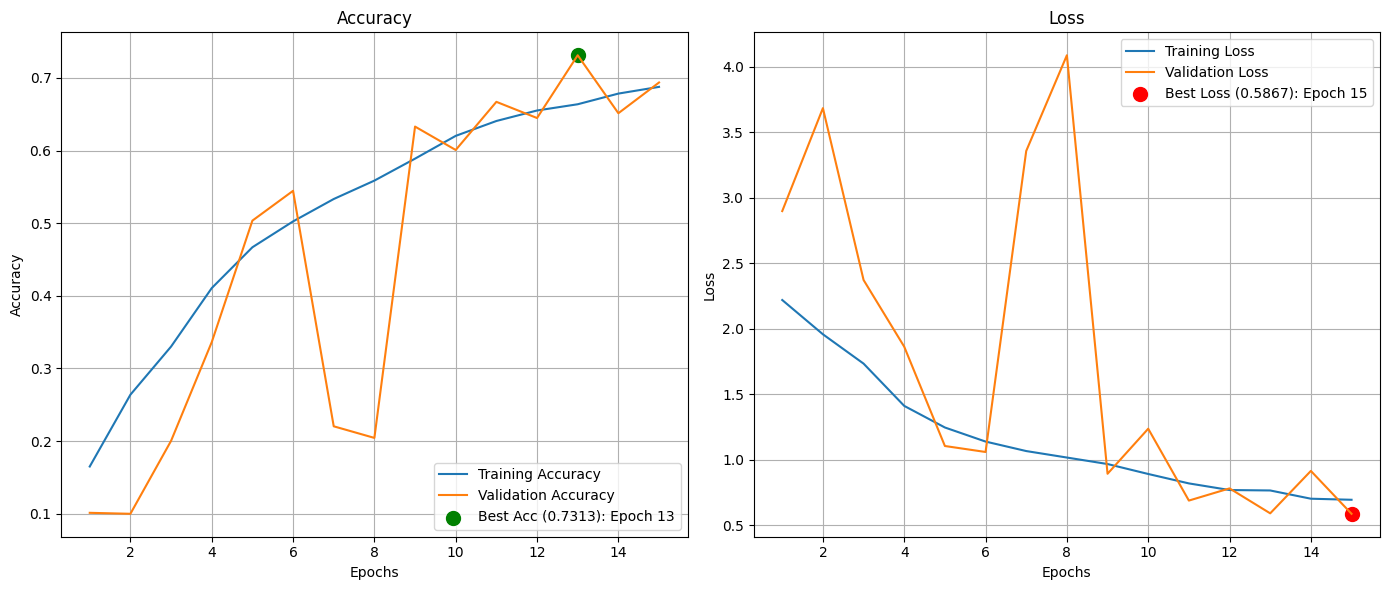

In [40]:
plot_learning_curves(history_optimizedqnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.69      0.65      0.67      4249
          06       0.00      0.00      0.00       401
          08       0.38      0.24      0.29      2748
          12       0.48      0.61      0.54      4633
          13       0.00      0.00      0.00      3429
          14       0.04      0.06      0.04      1139
          15       0.52      0.75      0.61      6421
          16       0.42      0.19      0.27      2061
          18       0.04      0.13      0.06      1058
          21       0.37      0.32      0.34      2899
          22       0.20      0.20      0.20       895
          23       0.73      0.31      0.44      2793
          27       0.76      0.82      0.79      1670
          30       0.76      0.55      0.64       803

    accuracy                           0.44     35199
   macro avg       0.38      0.35      0.35     35199
weighted avg       0.44      0.44      0.42     35

/home/mihaium2001/miniconda3/envs/QML/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mihaium2001/miniconda3/envs/QML/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mihaium2001/miniconda3/envs/QML/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

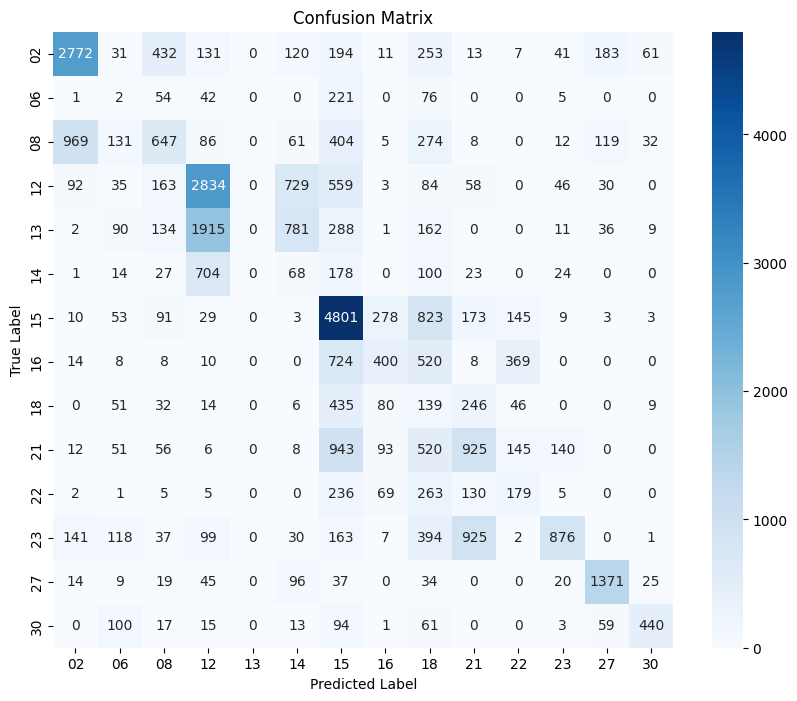

0.43904656382283586

In [41]:
evaluate_model(trained_model_optimizedqnn, test_loader, base_dataset.classes)

In [42]:
save_model(trained_model_optimizedqnn, model_path_optimizedqnn, model_name_optimizedqnn)

Saved model weights for HybridOptimizedQNN: HybridOptimizedQNN/HybridOptimizedQNN_Depolarizing.pth


## ResNet (Hybrid) + Quantum Head

### Define Model

In [35]:
model_name_qresnetqhead = "ResNetQuantumHead"
(MODEL_DIR / model_name_qresnetqhead).mkdir(parents=True, exist_ok=True)
model_path_qresnetqhead = f"{model_name_qresnetqhead}/{model_name_qresnetqhead}{NOISE_SUFFIX}.pth"

In [36]:
def make_qlayer_qresnetqhead():
    dev, nm = make_device_and_noise()
    
    @qml.qnode(dev, interface='torch')
    def quantum_circuit_qresnetqhead(inputs, weights):
        
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
        
    quantum_circuit_qresnetqhead = wrap_with_noise(quantum_circuit_qresnetqhead, nm)

    weight_shapes_qresnetqhead = {'weights': (N_LAYERS, N_QUBITS, 3)}
    
    qlayer_qresnetqhead = qnn.TorchLayer(quantum_circuit_qresnetqhead, weight_shapes_qresnetqhead)

    return qlayer_qresnetqhead

In [37]:
class ResNetQuantumHead(nn.Module):
    def __init__(self, num_classes, base_model=None):
        super().__init__()
        if base_model is None:
            base_model = models.resnet18(weights=None)
            base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base = base_model
        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.quantum_bridge = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, N_QUBITS),
            nn.BatchNorm1d(N_QUBITS)
        )
        self.q_layer = make_qlayer_qresnetqhead()
        self.fc_out = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.quantum_bridge(x)
        x = torch.tanh(x) * math.pi
        x = self.q_layer(x)
        x = self.fc_out(x)
        return x

In [38]:
backbone_qresnetqhead = models.resnet18(weights=None)
backbone_qresnetqhead.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [39]:
model_qresnetqhead = ResNetQuantumHead(num_classes=num_classes, base_model=backbone_qresnetqhead).to(DEVICE)

criterion_qresnetqhead = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qresnetqhead = optim.Adam(model_qresnetqhead.parameters(), lr=1e-3)

In [40]:
trained_model_qresnetqhead, history_qresnetqhead = train_model(model_name=model_name_qresnetqhead,
                                                               model=model_qresnetqhead,
                                                               criterion=criterion_qresnetqhead,
                                                               optimizer=optimizer_qresnetqhead,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=NUM_EPOCHS)

Starting training ResNetQuantumHead model for 15 epochs...

Epoch 1/15:
Train Loss: 1.8743 Acc: 0.2879
Val Loss: 1.3207 Acc: 0.3549
Epoch Time: 203.7s


Epoch 2/15:
Train Loss: 1.2023 Acc: 0.4774
Val Loss: 1.1883 Acc: 0.4468
Epoch Time: 202.9s


Epoch 3/15:
Train Loss: 0.8556 Acc: 0.5860
Val Loss: 0.6214 Acc: 0.6957
Epoch Time: 203.2s


Epoch 4/15:
Train Loss: 0.6008 Acc: 0.6937
Val Loss: 0.4988 Acc: 0.7198
Epoch Time: 203.7s


Epoch 5/15:
Train Loss: 0.5234 Acc: 0.7118
Val Loss: 0.4654 Acc: 0.7413
Epoch Time: 203.6s


Epoch 6/15:
Train Loss: 0.4448 Acc: 0.7901
Val Loss: 0.3337 Acc: 0.8304
Epoch Time: 203.3s


Epoch 7/15:
Train Loss: 0.3274 Acc: 0.8508
Val Loss: 0.2370 Acc: 0.8895
Epoch Time: 203.7s


Epoch 8/15:
Train Loss: 0.2378 Acc: 0.8980
Val Loss: 0.1617 Acc: 0.9215
Epoch Time: 201.8s


Epoch 9/15:
Train Loss: 0.1658 Acc: 0.9464
Val Loss: 0.0831 Acc: 0.9836
Epoch Time: 203.7s


Epoch 10/15:
Train Loss: 0.0919 Acc: 0.9820
Val Loss: 0.0450 Acc: 0.9886
Epoch Time: 203.2s


Epoch 11/

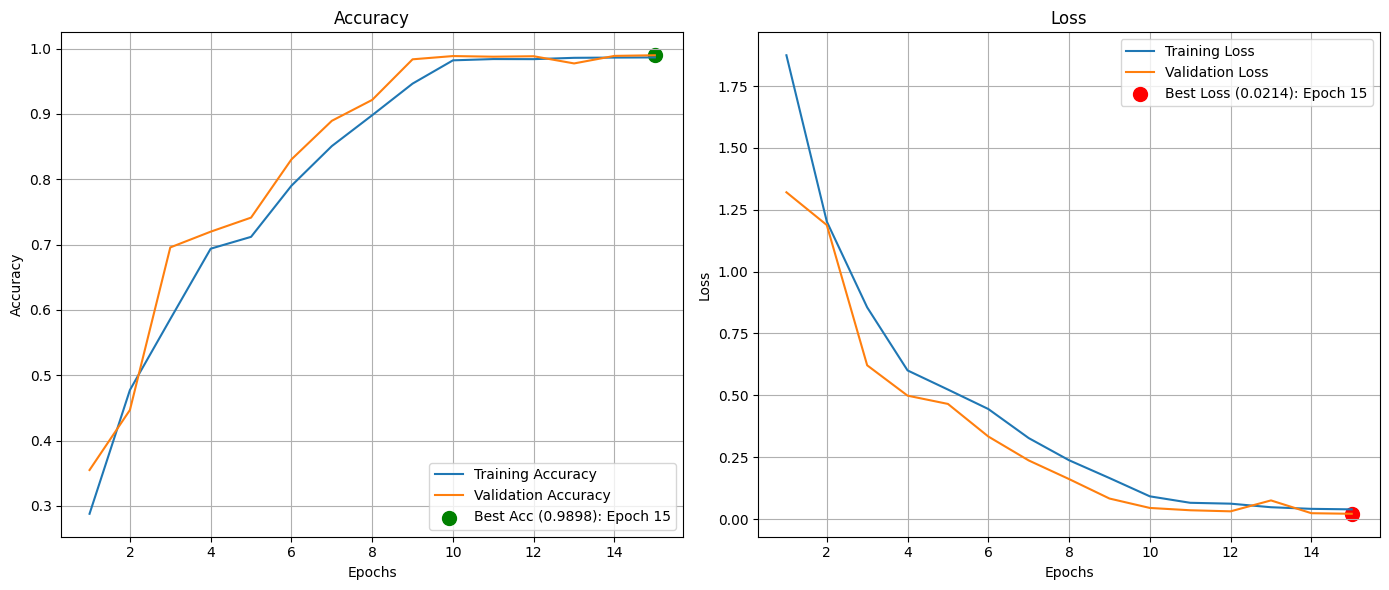

In [41]:
plot_learning_curves(history_qresnetqhead)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.88      0.90      0.89      4249
          06       0.69      0.09      0.16       401
          08       0.82      0.80      0.81      2748
          12       0.63      0.73      0.68      4633
          13       0.50      0.54      0.52      3429
          14       0.15      0.04      0.07      1139
          15       0.87      0.89      0.88      6421
          16       0.83      0.62      0.71      2061
          18       0.67      0.40      0.50      1058
          21       0.58      0.86      0.69      2899
          22       0.65      0.59      0.62       895
          23       0.95      0.83      0.88      2793
          27       0.78      0.90      0.84      1670
          30       1.00      0.79      0.89       803

    accuracy                           0.74     35199
   macro avg       0.71      0.64      0.65     35199
weighted avg       0.74      0.74      0.73     35

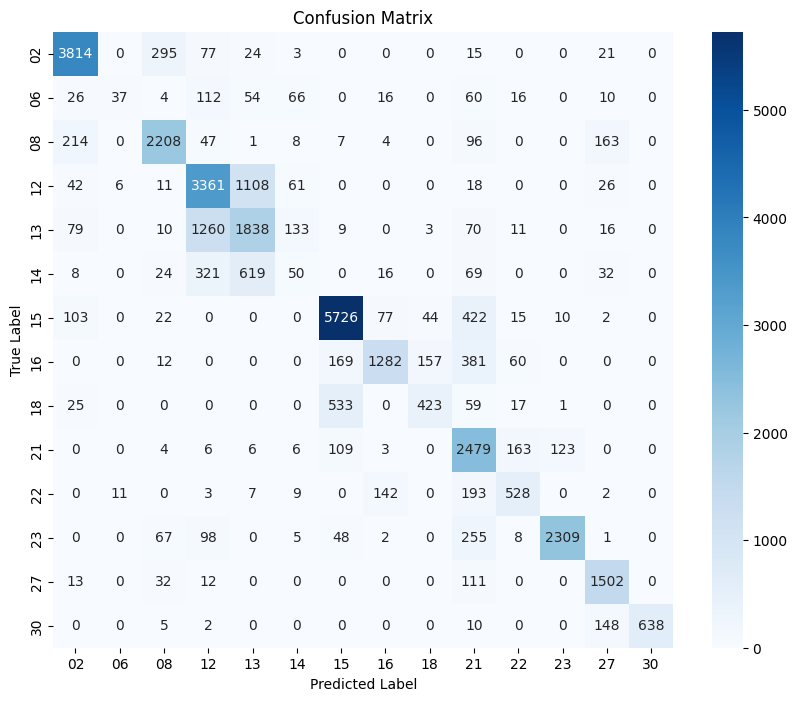

0.7441972783317707

In [42]:
evaluate_model(trained_model_qresnetqhead, test_loader, base_dataset.classes)

In [43]:
save_model(trained_model_qresnetqhead, model_path_qresnetqhead, model_name_qresnetqhead)

Saved model weights for ResNetQuantumHead: ResNetQuantumHead/ResNetQuantumHead_Depolarizing.pth


## Optimized QResNet

### Define Model

In [43]:
model_name_optimizedqresnet = "ViewOptimizedQResNet"
(MODEL_DIR / model_name_optimizedqresnet).mkdir(parents=True, exist_ok=True)
model_path_optimizedqresnet = f"{model_name_optimizedqresnet}/{model_name_optimizedqresnet}{NOISE_SUFFIX}.pth"

In [44]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()

        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += identity
        out = self.relu(out)
        
        return out

In [45]:
def make_qlayer_optimizedqresnet():
    dev, nm = make_device_and_noise()

    @qml.qnode(dev, interface='torch')
    def quantum_circuit_optimizedqresnet(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
    
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

    quantum_circuit_optimizedqresnet = wrap_with_noise(quantum_circuit_optimizedqresnet, nm)

    weight_shapes_optimizedqresnet = {"weights": (N_LAYERS, N_QUBITS, 3)}

    qlayer_optimizedqresnet = qnn.TorchLayer(quantum_circuit_optimizedqresnet, weight_shapes_optimizedqresnet)

    return qlayer_optimizedqresnet

In [46]:
class ViewOptimizedQResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewOptimizedQResNet, self).__init__()

        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.quantum_bridge = nn.Sequential(
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, N_QUBITS),
            nn.BatchNorm1d(N_QUBITS),
        )
        self.qlayer = make_qlayer_optimizedqresnet()
        self.fc_out = nn.Linear(N_QUBITS, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
            
        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # Quantum Block (with BatchNorm sandwich)
        x = self.quantum_bridge(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)
        return x

### Train & Save Model

In [47]:
model_optimizedqresnet = ViewOptimizedQResNet(num_classes=num_classes).to(DEVICE)

criterion_optimizedqresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqresnet = optim.Adam(model_optimizedqresnet.parameters(), lr=1e-3)

In [48]:
trained_model_optimizedqresnet, history_optimizedqresnet = train_model(model_name=model_name_optimizedqresnet,
                                                                       model=model_optimizedqresnet,
                                                                       criterion=criterion_optimizedqresnet,
                                                                       optimizer=optimizer_optimizedqresnet,
                                                                       train_loader=train_loader,
                                                                       val_loader=val_loader,
                                                                       num_epochs=NUM_EPOCHS)

Starting training ViewOptimizedQResNet model for 15 epochs...

Epoch 1/15:
Train Loss: 2.0413 Acc: 0.2714
Val Loss: 1.4525 Acc: 0.4132
Epoch Time: 203.8s


Epoch 2/15:
Train Loss: 1.2757 Acc: 0.4366
Val Loss: 1.0238 Acc: 0.5173
Epoch Time: 204.4s


Epoch 3/15:
Train Loss: 1.0487 Acc: 0.4824
Val Loss: 0.8665 Acc: 0.4854
Epoch Time: 204.8s


Epoch 4/15:
Train Loss: 0.8467 Acc: 0.6126
Val Loss: 0.5907 Acc: 0.7267
Epoch Time: 202.2s


Epoch 5/15:
Train Loss: 0.6100 Acc: 0.7107
Val Loss: 0.4359 Acc: 0.7995
Epoch Time: 202.5s


Epoch 6/15:
Train Loss: 0.5121 Acc: 0.7717
Val Loss: 0.3688 Acc: 0.8794
Epoch Time: 205.5s


Epoch 7/15:
Train Loss: 0.4070 Acc: 0.8656
Val Loss: 0.4225 Acc: 0.8546
Epoch Time: 205.2s


Epoch 8/15:
Train Loss: 0.2827 Acc: 0.9301
Val Loss: 0.1300 Acc: 0.9754
Epoch Time: 204.0s


Epoch 9/15:
Train Loss: 0.2229 Acc: 0.9480
Val Loss: 0.1196 Acc: 0.9729
Epoch Time: 201.8s


Epoch 10/15:
Train Loss: 0.2165 Acc: 0.9502
Val Loss: 0.1061 Acc: 0.9794
Epoch Time: 204.7s


Epoch 

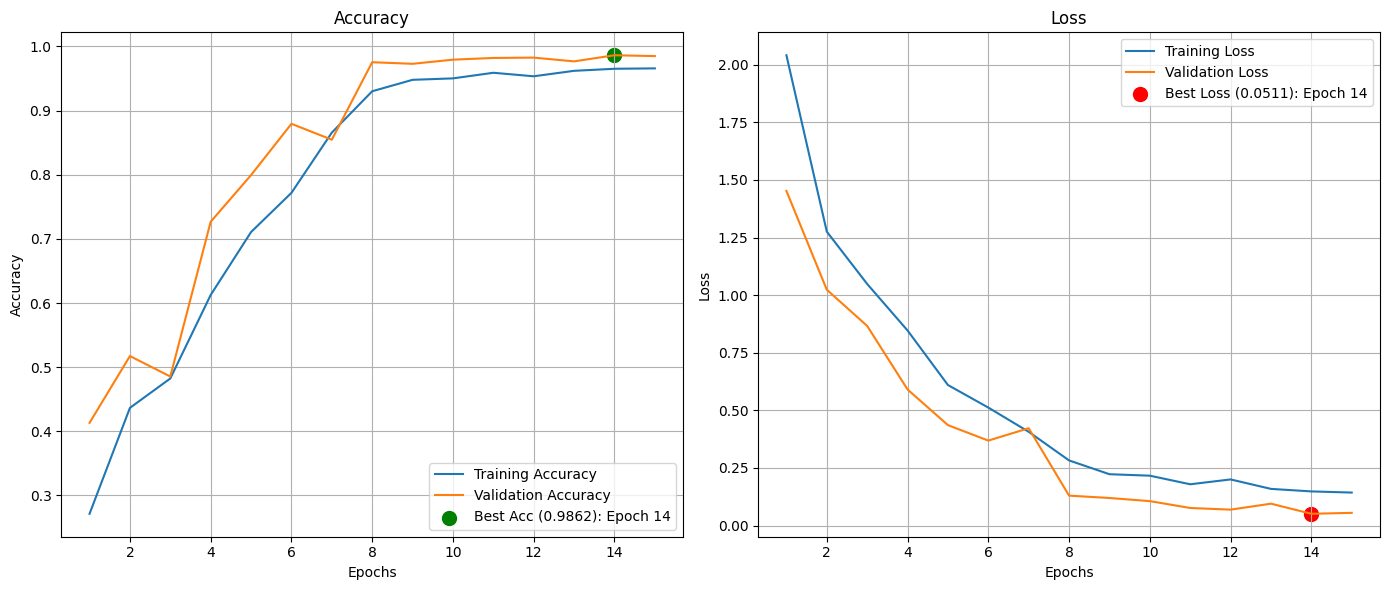

In [49]:
plot_learning_curves(history_optimizedqresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.98      0.88      0.92      4249
          06       0.27      0.05      0.09       401
          08       0.90      0.75      0.82      2748
          12       0.68      0.48      0.56      4633
          13       0.43      0.65      0.51      3429
          14       0.23      0.16      0.18      1139
          15       0.85      0.92      0.88      6421
          16       0.76      0.74      0.75      2061
          18       0.61      0.60      0.60      1058
          21       0.80      0.74      0.77      2899
          22       0.80      0.74      0.76       895
          23       0.92      0.81      0.86      2793
          27       0.63      0.93      0.75      1670
          30       0.51      0.80      0.62       803

    accuracy                           0.73     35199
   macro avg       0.67      0.66      0.65     35199
weighted avg       0.75      0.73      0.73     35

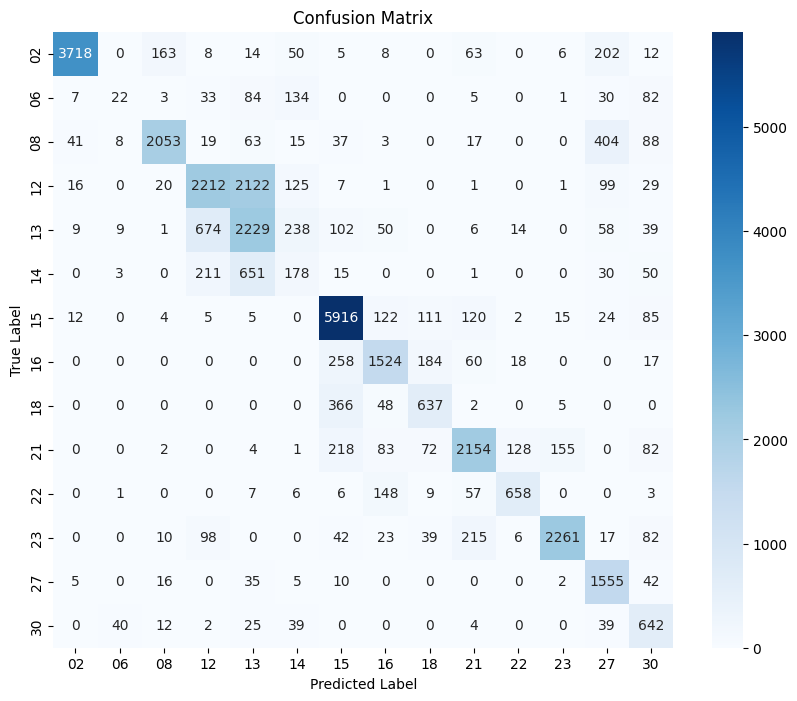

0.7318105628000795

In [50]:
evaluate_model(trained_model_optimizedqresnet, test_loader, base_dataset.classes)

In [51]:
save_model(trained_model_optimizedqresnet, model_path_optimizedqresnet, model_name_optimizedqresnet)

Saved model weights for ViewOptimizedQResNet: ViewOptimizedQResNet/ViewOptimizedQResNet_Depolarizing.pth


## Quantum Hopfield Network

### Define Model

In [53]:
class ModernHopfieldLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_stored_patterns: int,
        pattern_dim: int,
        num_heads: int = 4,
        beta_init: float = 1.0,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.num_stored_patterns = num_stored_patterns
        self.pattern_dim = pattern_dim
        self.num_heads = num_heads
        self.head_dim = pattern_dim // num_heads
        assert pattern_dim % num_heads == 0, "pattern_dim must be divisible by num_heads"

        # Learnable Inverse-Temperature (Sharpness of Attention)
        self.beta = nn.Parameter(torch.tensor(beta_init))

        # Learnable Stored Patterns (The Associative Memory)
        self.stored_patterns = nn.Parameter(
            torch.randn(num_stored_patterns, pattern_dim) * 0.02
        )

        # Multi-Head Projections
        self.query_proj = nn.Linear(input_dim, pattern_dim)
        self.key_proj   = nn.Linear(pattern_dim, pattern_dim)
        self.value_proj = nn.Linear(pattern_dim, pattern_dim)
        self.out_proj   = nn.Linear(pattern_dim, pattern_dim)

        # Stability Helpers
        self.layer_norm = nn.LayerNorm(pattern_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        B = x.size(0)
        H = self.num_heads
        D = self.head_dim
        N = self.num_stored_patterns

        # Project Input -> Query
        query = self.query_proj(x) # (B, pattern_dim)

        # Keys and Values from Stored Patterns
        keys   = self.key_proj(self.stored_patterns)   # (N, pattern_dim)
        values = self.value_proj(self.stored_patterns) # (N, pattern_dim)

        # Reshape for Multi-Head Attention
        query  = query.view(B, H, D)                   # (B, H, D)
        keys   = keys.view(N, H, D).permute(1, 2, 0)   # (H, D, N)
        values = values.view(N, H, D).permute(1, 0, 2) # (H, N, D)

        # Scaled Dot-Product Attention with Learnable Temperature
        attn_logits = torch.einsum("bhd,hdn->bhn", query, keys) # (B, H, N)
        attn_logits = self.beta * attn_logits / (D ** 0.5)
        attn_weights = F.softmax(attn_logits, dim=-1)           # (B, H, N)
        attn_weights = self.dropout(attn_weights)

        # Retrieve Patterns
        retrieved = torch.einsum("bhn,hnd->bhd", attn_weights, values) # (B, H, D)
        retrieved = retrieved.reshape(B, -1)                           # (B, pattern_dim)
        retrieved = self.out_proj(retrieved)
        
        # Residual Connection + LayerNorm
        output = self.layer_norm(query.reshape(B, -1) + retrieved)
        
        return output, attn_weights

In [54]:
model_name_qhopfield = "ResNetQuantumHopfield"
(MODEL_DIR / model_name_qhopfield).mkdir(parents=True, exist_ok=True)
model_path_qhopfield = f"{model_name_qhopfield}/{model_name_qhopfield}{NOISE_SUFFIX}.pth"

In [55]:
def make_qlayer_qhopfield():
    dev, nm = make_device_and_noise()

    @qml.qnode(dev, interface="torch")
    def quantum_circuit_qhopfield(inputs, weights_entangle, weights_ry):    
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))

        qml.templates.StronglyEntanglingLayers(weights_entangle, wires=range(N_QUBITS))

        for i in range(N_QUBITS):
            qml.RY(weights_ry[i], wires=i)

        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

    quantum_circuit_qhopfield = wrap_with_noise(quantum_circuit_qhopfield, nm)

    weight_shapes_qhopfield = {"weights_entangle": (N_LAYERS, N_QUBITS, 3),
                               "weights_ry":       (N_QUBITS,)}

    qlayer_qhopfield = qnn.TorchLayer(quantum_circuit_qhopfield, weight_shapes_qhopfield)

    return qlayer_qhopfield

In [56]:
class ResNetQuantumHopfield(nn.Module):
    def __init__(
        self,
        num_classes: int,
        base_model: nn.Module = None,
        hopfield_dim: int = 128,
        num_prototypes_per_class: int = 4,
        hopfield_heads: int = 4,
        hopfield_beta: float = 2.0,
        dropout: float = 0.3,
    ):
        super().__init__()
        if base_model is None:
            base_model = models.resnet18(weights=None)
            base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # ResNet Backbone
        self.base = base_model
        in_features = self.base.fc.in_features # Typically 512 for ResNet-18
        self.base.fc = nn.Identity()

        # Project ResNet Features -> Hopfield Input Space
        self.fc_proj = nn.Sequential(
            nn.Linear(in_features, hopfield_dim),
            nn.BatchNorm1d(hopfield_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Modern Hopfield Layer
        num_stored = num_classes * num_prototypes_per_class
        self.hopfield = ModernHopfieldLayer(
            input_dim=hopfield_dim,
            num_stored_patterns=num_stored,
            pattern_dim=hopfield_dim,
            num_heads=hopfield_heads,
            beta_init=hopfield_beta,
            dropout=dropout)

        # Bridge: Hopfield Output -> Quantum Input
        self.fc_to_q = nn.Sequential(
            nn.Linear(hopfield_dim, N_QUBITS),
            nn.Tanh() # squash into [-1, 1] for angle encoding
        )

        # Quantum Refinement Layer
        self.q_layer = make_qlayer_qhopfield()

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(N_QUBITS, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # ResNet Feature Extraction
        features = self.base(x) # (B, 512)

        # Project to Hopfield Space
        h = self.fc_proj(features) # (B, hopfield_dim)

        # Hopfield Associative Retrieval
        h, _attn = self.hopfield(h) # (B, hopfield_dim)

        # Bridge to Quantum
        q_input = self.fc_to_q(h) * math.pi # (B, n_qubits) scaled to [-pi, pi]

        # Quantum Refinement
        q_output = self.q_layer(q_input) # (B, n_qubits)

        # Classify
        logits = self.classifier(q_output) # (B, num_classes)
        return logits

In [57]:
backbone_qhopfield = models.resnet18(weights=None)
backbone_qhopfield.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [58]:
model_qhopfield = ResNetQuantumHopfield(num_classes=num_classes,
                                        base_model=backbone_qhopfield,
                                        hopfield_dim=128,
                                        num_prototypes_per_class=4, # 4 prototypes x 14 classes = 56 stored patterns
                                        hopfield_heads=4,
                                        hopfield_beta=2.0,
                                        dropout=0.3).to(DEVICE)

criterion_qhopfield = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer_qhopfield = optim.Adam(model_qhopfield.parameters(), lr=1e-3)

In [59]:
trained_model_qhopfield, history_qhopfield = train_model(model_name=model_name_qhopfield,
                                                         model=model_qhopfield,
                                                         criterion=criterion_qhopfield,
                                                         optimizer=optimizer_qhopfield,
                                                         train_loader=train_loader,
                                                         val_loader=val_loader,
                                                         num_epochs=NUM_EPOCHS)

Starting training ResNetQuantumHopfield model for 15 epochs...

Epoch 1/15:
Train Loss: 2.0402 Acc: 0.2650
Val Loss: 1.4006 Acc: 0.4641
Epoch Time: 221.3s


Epoch 2/15:
Train Loss: 1.1204 Acc: 0.7054
Val Loss: 0.8404 Acc: 0.8009
Epoch Time: 223.4s


Epoch 3/15:
Train Loss: 0.8442 Acc: 0.8607
Val Loss: 0.7404 Acc: 0.9263
Epoch Time: 224.2s


Epoch 4/15:
Train Loss: 0.7268 Acc: 0.9495
Val Loss: 0.6717 Acc: 0.9579
Epoch Time: 225.6s


Epoch 5/15:
Train Loss: 0.6750 Acc: 0.9763
Val Loss: 0.6198 Acc: 0.9846
Epoch Time: 224.2s


Epoch 6/15:
Train Loss: 0.6560 Acc: 0.9821
Val Loss: 0.6189 Acc: 0.9862
Epoch Time: 224.8s


Epoch 7/15:
Train Loss: 0.6449 Acc: 0.9840
Val Loss: 0.7319 Acc: 0.9528
Epoch Time: 226.2s


Epoch 8/15:
Train Loss: 0.6387 Acc: 0.9849
Val Loss: 0.5985 Acc: 0.9901
Epoch Time: 224.1s


Epoch 9/15:
Train Loss: 0.6354 Acc: 0.9856
Val Loss: 0.5994 Acc: 0.9896
Epoch Time: 226.6s


Epoch 10/15:
Train Loss: 0.6330 Acc: 0.9860
Val Loss: 0.6139 Acc: 0.9852
Epoch Time: 225.3s


Epoch

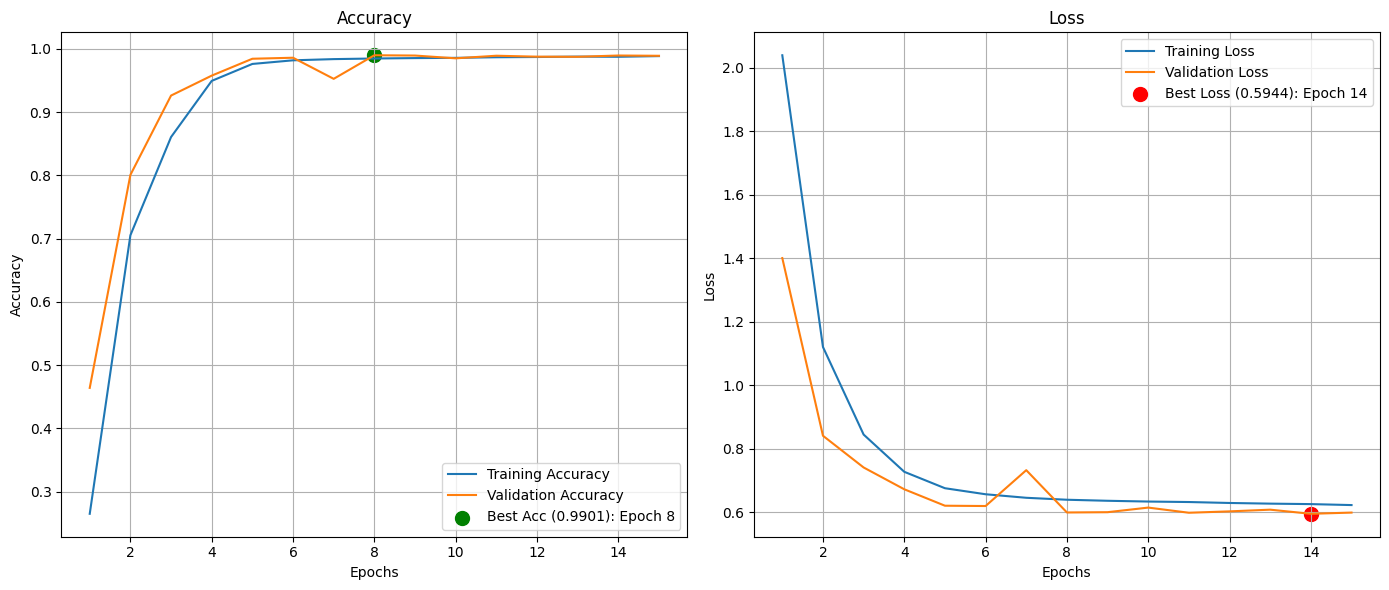

In [60]:
plot_learning_curves(history_qhopfield)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.84      0.94      0.89      4249
          06       0.05      0.01      0.02       401
          08       0.82      0.83      0.82      2748
          12       0.59      0.64      0.61      4633
          13       0.51      0.64      0.56      3429
          14       0.18      0.05      0.08      1139
          15       0.82      0.90      0.86      6421
          16       0.76      0.68      0.72      2061
          18       0.69      0.64      0.66      1058
          21       0.86      0.78      0.82      2899
          22       0.78      0.49      0.60       895
          23       0.92      0.87      0.90      2793
          27       0.99      0.83      0.90      1670
          30       0.87      0.93      0.90       803

    accuracy                           0.76     35199
   macro avg       0.69      0.66      0.67     35199
weighted avg       0.74      0.76      0.75     35

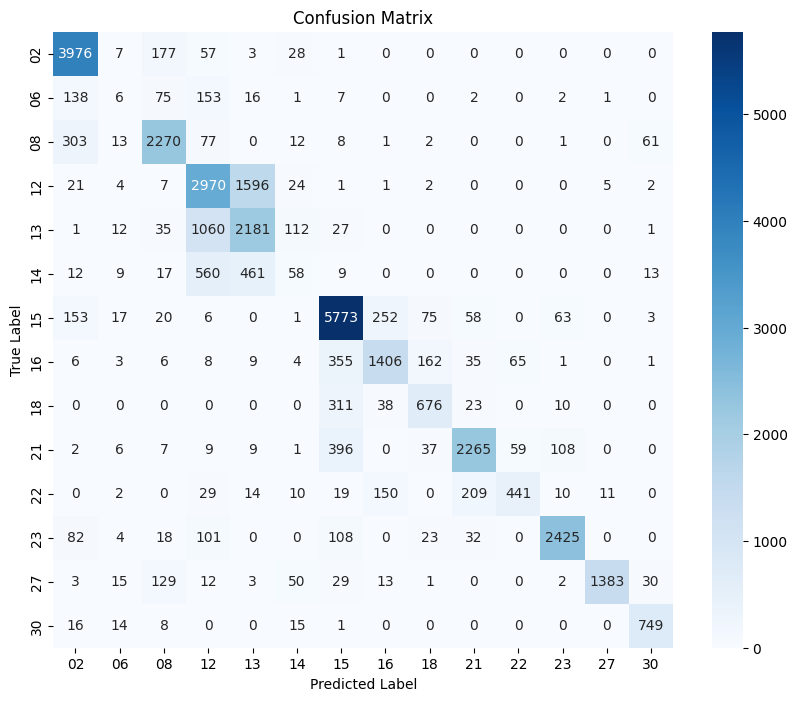

0.7551066791670218

In [61]:
evaluate_model(trained_model_qhopfield, test_loader, base_dataset.classes)

In [62]:
save_model(trained_model_qhopfield, model_path_qhopfield, model_name_qhopfield)

Saved model weights for ResNetQuantumHopfield: ResNetQuantumHopfield/ResNetQuantumHopfield_Depolarizing.pth


## Quantum-Classical Dual-Path Network

### Define Model

In [63]:
class FocalLoss_dp(nn.Module):
    """
    Focal Loss (Lin et al., 2017) – down-weights easy examples so the
    model concentrates on the confused classes (15/23, 12/13, etc.).

        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets,
                                  weight=self.weight,
                                  reduction='none',
                                  label_smoothing=self.label_smoothing)
        
        pt = torch.exp(-ce_loss) # p_t for each sample
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [64]:
aug_tf_dp = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
}

In [65]:
train_data_aug_dp = TransformedSubset(train_subset, transform=aug_tf_dp['train'])
val_data_aug_dp   = TransformedSubset(val_subset,   transform=aug_tf_dp['val'])

train_loader_aug_dp = DataLoader(train_data_aug_dp, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_aug_dp   = DataLoader(val_data_aug_dp,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"Augmented data: Train: {len(train_data_aug_dp)}; Validation: {len(val_data_aug_dp)}")

Augmented data: Train: 140115; Validation: 35029


In [66]:
model_name_dp = "DualPathQuantumNet"
(MODEL_DIR / model_name_dp).mkdir(parents=True, exist_ok=True)
model_path_dp = f"{model_name_dp}/{model_name_dp}{NOISE_SUFFIX}.pth"

In [67]:
def make_qlayer_dp():
    dev, nm = make_device_and_noise()

    @qml.qnode(dev, interface="torch")
    def quantum_circuit_dp(inputs, weights_ent, weights_ry):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
    
        qml.templates.StronglyEntanglingLayers(weights_ent, wires=range(N_QUBITS))
    
        for i in range(N_QUBITS):
            qml.RY(weights_ry[i], wires=i)
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

    quantum_circuit_dp = wrap_with_noise(quantum_circuit_dp, nm)

    qlayer_dp = qnn.TorchLayer(quantum_circuit_dp, {"weights_ent": (N_LAYERS, N_QUBITS, 3),
                                                    "weights_ry":  (N_QUBITS,)})

    return qlayer_dp

In [68]:
resnet18_pretrained_state = None

def get_pretrained_resnet18_gray():
    
    global resnet18_pretrained_state
    
    if resnet18_pretrained_state is None:
        # Pretrained ResNet-18, Adapted For 1-Channel
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        # Adapt First Conv: Average RGB -> Grayscale
        orig_w = backbone.conv1.weight.data # (64, 3, 7, 7)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = orig_w.mean(dim=1, keepdim=True) # (64, 1, 7, 7)
        resnet18_pretrained_state = backbone.state_dict()
        
    backbone = models.resnet18(weights=None)
    backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    backbone.load_state_dict(resnet18_pretrained_state)
    return backbone

In [69]:
class DualPathQuantumNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        backbone = get_pretrained_resnet18_gray()
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        # Freeze Early Layers For Faster Convergence & Less Overfitting
        for name, param in backbone.named_parameters():
            if 'layer1' in name or 'conv1' in name or 'bn1' in name:
                param.requires_grad = False
                
        self.backbone = backbone

        # Classical Path
        self.classical = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        # Quantum Path
        self.q_bridge = nn.Sequential(
            nn.Linear(in_features, N_QUBITS),
            nn.Tanh()
        )
        self.q_layer = make_qlayer_dp()
        self.q_expand = nn.Sequential(
            nn.Linear(N_QUBITS, 64),
            nn.GELU()
        )

        # Fusion + Classifier
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(256 + 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256 + 64, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)                  # (B, 512)

        # Classical Path
        c_out = self.classical(feat)             # (B, 256)

        # Quantum Path
        q_in  = self.q_bridge(feat) * math.pi    # (B, 8)
        q_out = self.q_layer(q_in)               # (B, 8)
        q_out = self.q_expand(q_out)             # (B, 64)

        # Fuse and Classify
        fused = torch.cat([c_out, q_out], dim=1) # (B, 320)
        return self.classifier(fused)            # (B, num_classes)

In [70]:
def train_model_dp(model_name, model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs):
    """Enhanced training loop with LR scheduling + timing."""
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    print(f"Training {model_name} for {num_epochs} epochs...")
    print(f"   LR schedule: CosineAnnealing, Initial LR = {optimizer.param_groups[0]['lr']}")
    print()

    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}  (lr={lr_now:.6f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        # Step The Scheduler After Each Epoch
        scheduler.step()

        epoch_elapsed = time.time() - epoch_start
        history['epoch_times'].append(epoch_elapsed)
        print(f"   Epoch Time: {epoch_elapsed:.1f}s")
        print()

    total_elapsed = time.time() - total_start
    history['total_time'] = total_elapsed

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Total Training Time: {total_elapsed:.1f}s ({total_elapsed/60:.1f}m)")
    print(f"Average Epoch Time:  {np.mean(history['epoch_times']):.1f}s")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [71]:
model_dp = DualPathQuantumNet(num_classes=num_classes).to(DEVICE)

criterion_dp = FocalLoss_dp(weight=class_weights_tensor, gamma=2.0, label_smoothing=0.1)
optimizer_dp = optim.AdamW(model_dp.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_dp = CosineAnnealingLR(optimizer_dp, T_max=NUM_EPOCHS, eta_min=1e-6)

In [72]:
trained_model_dp, history_dp = train_model_dp(model_name=model_name_dp,
                                              model=model_dp,
                                              criterion=criterion_dp,
                                              optimizer=optimizer_dp,
                                              scheduler=scheduler_dp,
                                              train_loader=train_loader_aug_dp,
                                              val_loader=val_loader_aug_dp,
                                              num_epochs=NUM_EPOCHS)

Training DualPathQuantumNet for 15 epochs...
   LR schedule: CosineAnnealing, Initial LR = 0.0003

Epoch 1/15  (lr=0.000300):
   train Loss: 0.6225  Acc: 0.7601
   val   Loss: 0.8861  Acc: 0.7172
   Epoch Time: 173.3s

Epoch 2/15  (lr=0.000297):
   train Loss: 0.3391  Acc: 0.8925
   val   Loss: 0.7377  Acc: 0.7639
   Epoch Time: 173.7s

Epoch 3/15  (lr=0.000287):
   train Loss: 0.2720  Acc: 0.9253
   val   Loss: 0.5398  Acc: 0.8314
   Epoch Time: 175.6s

Epoch 4/15  (lr=0.000271):
   train Loss: 0.2372  Acc: 0.9435
   val   Loss: 0.4839  Acc: 0.8659
   Epoch Time: 175.7s

Epoch 5/15  (lr=0.000251):
   train Loss: 0.2145  Acc: 0.9533
   val   Loss: 0.4122  Acc: 0.8855
   Epoch Time: 175.2s

Epoch 6/15  (lr=0.000225):
   train Loss: 0.1989  Acc: 0.9610
   val   Loss: 0.4662  Acc: 0.8667
   Epoch Time: 175.6s

Epoch 7/15  (lr=0.000197):
   train Loss: 0.1878  Acc: 0.9663
   val   Loss: 0.4062  Acc: 0.8839
   Epoch Time: 177.3s

Epoch 8/15  (lr=0.000166):
   train Loss: 0.1761  Acc: 0.9720

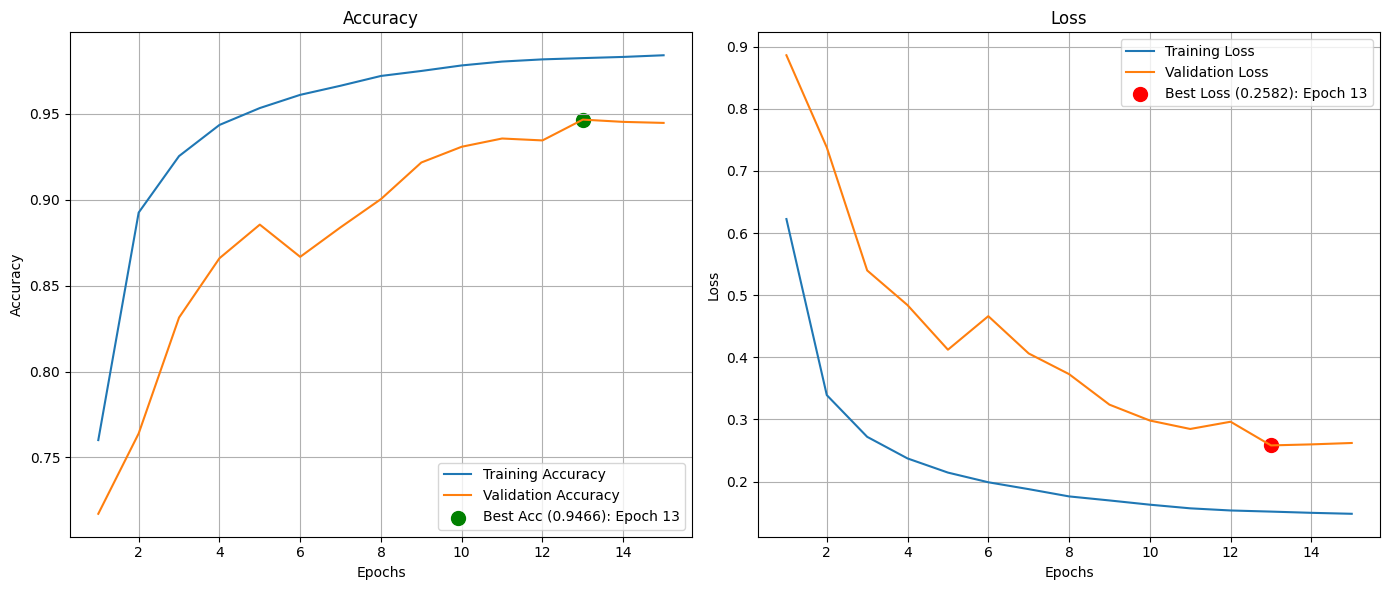

In [73]:
plot_learning_curves(history_dp)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.83      0.96      0.89      4249
          06       1.00      0.18      0.30       401
          08       0.87      0.86      0.86      2748
          12       0.60      0.72      0.65      4633
          13       0.51      0.54      0.53      3429
          14       0.29      0.03      0.06      1139
          15       0.84      0.89      0.86      6421
          16       0.99      0.43      0.60      2061
          18       0.95      0.17      0.28      1058
          21       0.64      0.88      0.74      2899
          22       0.56      0.11      0.19       895
          23       0.58      0.92      0.71      2793
          27       1.00      0.74      0.85      1670
          30       0.98      0.58      0.73       803

    accuracy                           0.72     35199
   macro avg       0.76      0.57      0.59     35199
weighted avg       0.74      0.72      0.70     35

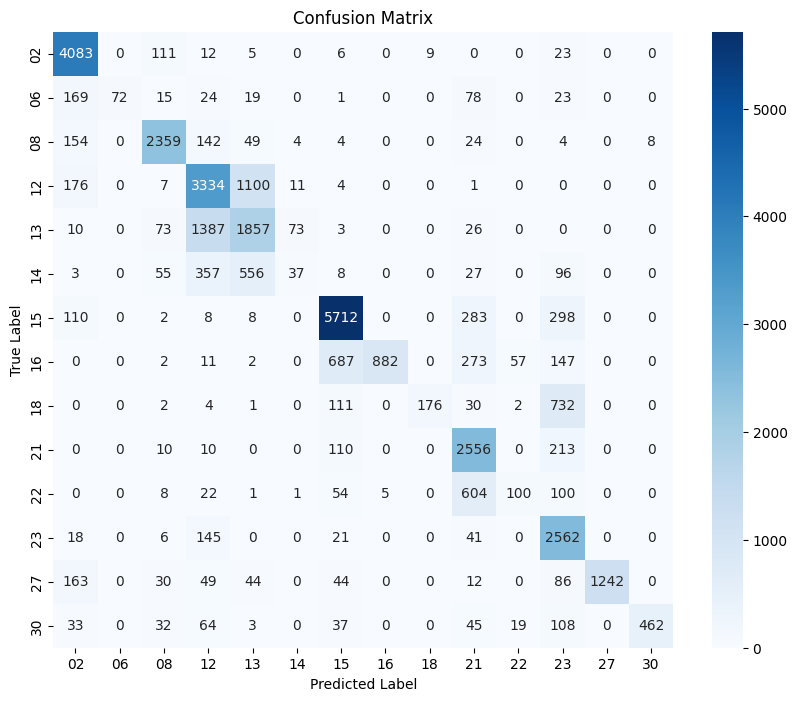

0.722577345947328

In [74]:
evaluate_model(trained_model_dp, test_loader, base_dataset.classes)

In [75]:
save_model(trained_model_dp, model_path_dp, model_name_dp)

Saved model weights for DualPathQuantumNet: DualPathQuantumNet/DualPathQuantumNet_Depolarizing.pth


# NISQ Testing - Literature Baseline-Inspired Models

## PHN

### Define Model

In [76]:
model_name_phn = "PHN"
(MODEL_DIR / model_name_phn).mkdir(parents=True, exist_ok=True)
model_path_phn = f"{model_name_phn}/{model_name_phn}{NOISE_SUFFIX}.pth"

In [77]:
def make_qlayer_phn():
    dev, nm = make_device_and_noise()

    @qml.qnode(dev, interface="torch")
    def quantum_circuit_phn(inputs, weights):
        """
        PHN VQC (Kordzanganeh et al., 2023).

        Paper §III: "a generalised data re-uploading VQC [...]
        in alternation, a series of variational and encoding
        layers are applied."

        Structure per layer:
          S(x) - AngleEmbedding (data re-uploaded each layer)
          U(θ) - StronglyEntanglingLayers (single variational layer)
        Measurement: PauliZ on each qubit.
        """
        for layer in range(N_LAYERS):
            # S(x): encoding layer (data re-uploading)
            qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
            # U(θ): variational layer
            qml.templates.StronglyEntanglingLayers(weights[layer:layer+1], wires=range(N_QUBITS))

        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

    quantum_circuit_phn = wrap_with_noise(quantum_circuit_phn, nm)

    weight_shapes_phn = {"weights": (N_LAYERS, N_QUBITS, 3)}

    qlayer_phn = qnn.TorchLayer(quantum_circuit_phn, weight_shapes_phn)

    return qlayer_phn

In [78]:
class PHN(nn.Module):
    def __init__(self, num_classes):
        super(PHN, self).__init__()

        # Shared CNN feature extractor (adaptation for image input)
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        feature_dim = 32

        # MLP branch (paper Appendix A adapted for classification: single hidden layer, 256 neurons, ReLU hidden activation, raw logit output)
        self.mlp_hidden = nn.Linear(feature_dim, 256)
        self.mlp_out = nn.Linear(256, num_classes)

        # VQC branch
        self.fc_to_q = nn.Linear(feature_dim, N_QUBITS)
        self.qlayer = make_qlayer_phn()
        self.fc_q_out = nn.Linear(N_QUBITS, num_classes)

        # Linear combination weights (paper §III):
        # o_i = s^c_i * c_i + s^q_i * q_i  (per-output trainable scalars)
        self.s_classical = nn.Parameter(torch.ones(num_classes))
        self.s_quantum = nn.Parameter(torch.ones(num_classes))

    def forward(self, x):
        feat = self.features(x)
        feat = feat.view(feat.size(0), -1)        # (B, 32)

        # MLP branch
        mlp_h = torch.relu(self.mlp_hidden(feat)) # (B, 256)
        c_out = self.mlp_out(mlp_h)               # (B, num_classes)
        
        # VQC branch
        q_in = self.fc_to_q(feat)                 # (B, n_qubits)
        q_in = torch.tanh(q_in) * math.pi         # scale to [-pi, pi]
        q_feat = self.qlayer(q_in)                # (B, n_qubits)
        q_out = self.fc_q_out(q_feat)             # (B, num_classes)

        # Linear combination (paper §III)
        output = self.s_classical * c_out + self.s_quantum * q_out
        
        return output

### Train & Save Model

In [79]:
model_phn = PHN(num_classes=num_classes).to(DEVICE)

criterion_phn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_phn = torch.optim.Adam(model_phn.parameters(), lr=1e-3)

In [80]:
trained_model_phn, history_phn = train_model(model_name=model_name_phn,
                                             model=model_phn,
                                             criterion=criterion_phn,
                                             optimizer=optimizer_phn,
                                             train_loader=train_loader,
                                             val_loader=val_loader,
                                             num_epochs=NUM_EPOCHS)

Starting training PHN model for 15 epochs...

Epoch 1/15:
Train Loss: 1.9999 Acc: 0.2980
Val Loss: 1.6629 Acc: 0.3889
Epoch Time: 151.0s


Epoch 2/15:
Train Loss: 1.4763 Acc: 0.4644
Val Loss: 1.3096 Acc: 0.5016
Epoch Time: 153.6s


Epoch 3/15:
Train Loss: 1.2221 Acc: 0.5440
Val Loss: 1.1247 Acc: 0.5678
Epoch Time: 151.4s


Epoch 4/15:
Train Loss: 1.0567 Acc: 0.6012
Val Loss: 0.9943 Acc: 0.6217
Epoch Time: 153.6s


Epoch 5/15:
Train Loss: 0.9275 Acc: 0.6434
Val Loss: 0.9269 Acc: 0.6410
Epoch Time: 153.0s


Epoch 6/15:
Train Loss: 0.8309 Acc: 0.6789
Val Loss: 0.7647 Acc: 0.7009
Epoch Time: 154.2s


Epoch 7/15:
Train Loss: 0.7529 Acc: 0.7059
Val Loss: 0.7024 Acc: 0.7218
Epoch Time: 153.9s


Epoch 8/15:
Train Loss: 0.6763 Acc: 0.7355
Val Loss: 0.6397 Acc: 0.7531
Epoch Time: 152.1s


Epoch 9/15:
Train Loss: 0.6087 Acc: 0.7593
Val Loss: 0.5968 Acc: 0.7708
Epoch Time: 154.6s


Epoch 10/15:
Train Loss: 0.5579 Acc: 0.7781
Val Loss: 0.5384 Acc: 0.7886
Epoch Time: 150.5s


Epoch 11/15:
Train Loss

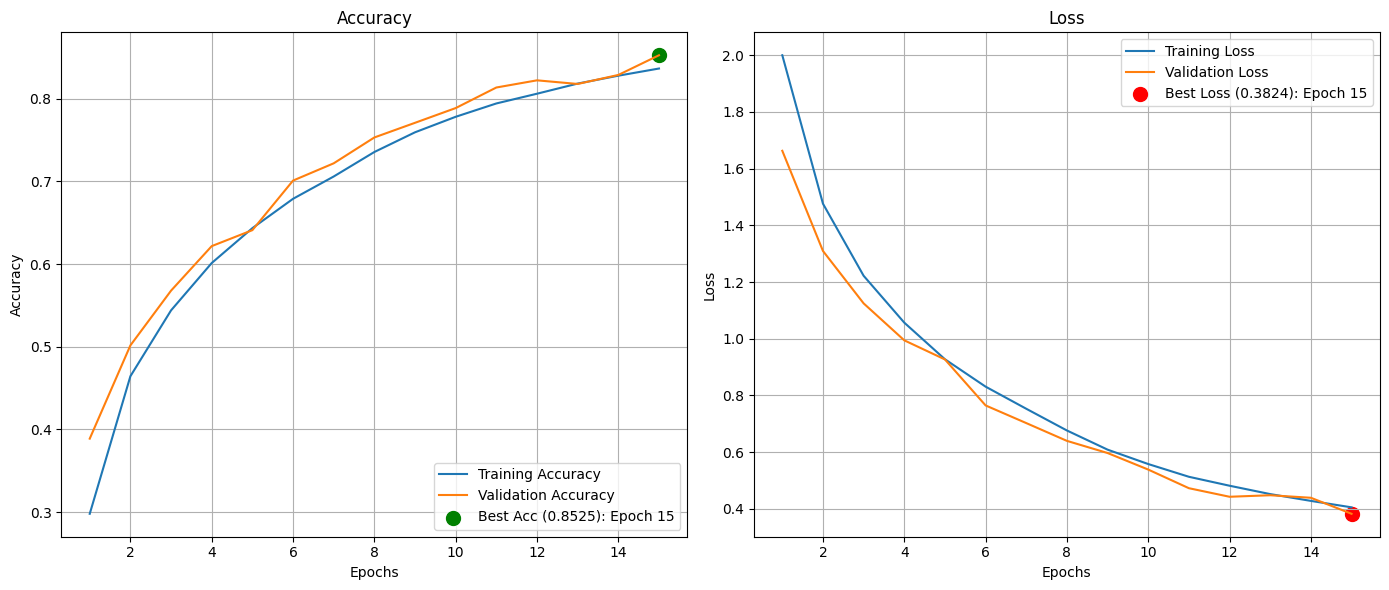

In [81]:
plot_learning_curves(history_phn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.85      0.64      0.73      4249
          06       0.00      0.00      0.00       401
          08       0.41      0.57      0.47      2748
          12       0.41      0.51      0.45      4633
          13       0.39      0.37      0.38      3429
          14       0.09      0.04      0.05      1139
          15       0.63      0.72      0.67      6421
          16       0.43      0.61      0.50      2061
          18       0.17      0.10      0.13      1058
          21       0.47      0.46      0.47      2899
          22       0.51      0.20      0.29       895
          23       0.52      0.42      0.47      2793
          27       0.57      0.61      0.59      1670
          30       0.68      0.41      0.51       803

    accuracy                           0.51     35199
   macro avg       0.44      0.40      0.41     35199
weighted avg       0.51      0.51      0.50     35

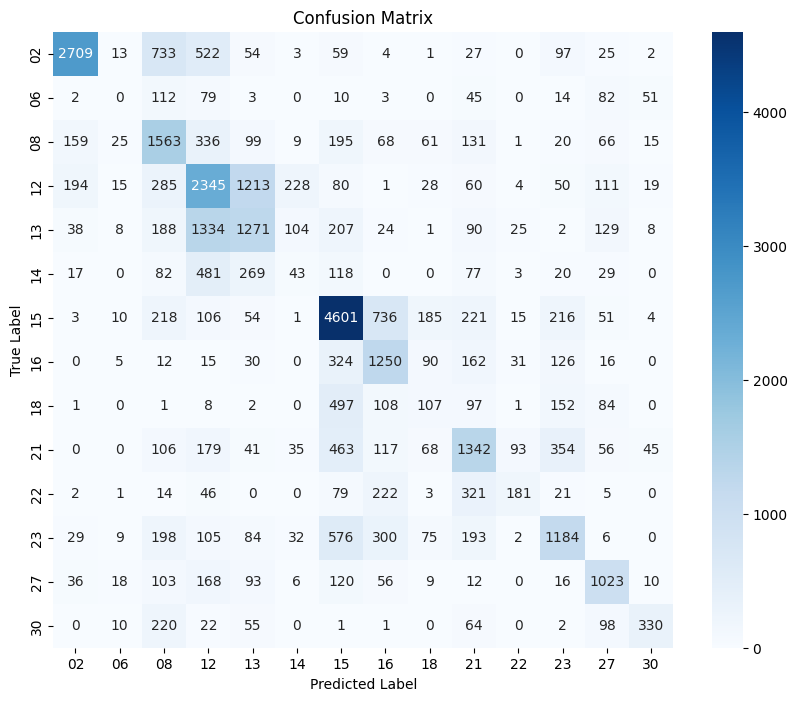

0.5099292593539589

In [82]:
evaluate_model(trained_model_phn, test_loader, base_dataset.classes)

In [83]:
save_model(trained_model_phn, model_path_phn, model_name_phn)

Saved model weights for PHN: PHN/PHN_Depolarizing.pth


# NISQ Testing - QuantumBoost Models

## QuantumBoost (V1)

### Define Model

In [52]:
model_name_qboostv1 = "QuantumBoostNetV1"
(MODEL_DIR / model_name_qboostv1).mkdir(parents=True, exist_ok=True)
model_path_qboostv1 = f"{model_name_qboostv1}/{model_name_qboostv1}{NOISE_SUFFIX}.pth"

In [53]:
def make_qlayer_qboostv1():
    dev, nm = make_device_and_noise()
    
    @qml.qnode(dev, interface="torch")
    def quantum_circuit_qboostv1(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
        
    quantum_circuit_qboostv1 = wrap_with_noise(quantum_circuit_qboostv1, nm)

    weight_shapes_qboostv1 = {"weights": (N_LAYERS, N_QUBITS, 3)}
    
    qlayer_qboostv1 = qnn.TorchLayer(quantum_circuit_qboostv1, weight_shapes_qboostv1)
    
    return qlayer_qboostv1

In [54]:
class QuantumBoostNetV1(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNetV1, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, N_QUBITS)
        self.qlayer = make_qlayer_qboostv1()
        self.fc_q_out = nn.Linear(N_QUBITS, num_classes)

        # Classical Boost Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        # Learnable Mixing Gate
        self.gate = nn.Parameter(torch.tensor(3.0))

        # Freeze Classical Head Initially
        self._freeze_classical_head()
        self._boost_enabled = False

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
            
        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers

    def _freeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = False

    def _unfreeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = True

    def enable_boost(self):
        if self._boost_enabled:
            return
            
        self._boost_enabled = True
        self._unfreeze_classical_head()

        # Freeze Quantum Path
        self.fc_to_q.requires_grad_(False)
        for param in self.qlayer.parameters():
            param.requires_grad = False
        self.fc_q_out.requires_grad_(False)
        
        print("   [QuantumBoostNetV1] Boost enabled: classical head unfrozen, quantum path frozen.")

    def set_alpha(self, target_alpha):
        target_alpha = max(0.01, min(0.99, target_alpha))
        self.gate.data = torch.tensor(math.log(target_alpha / (1 - target_alpha)), device=self.gate.device)

    @property
    def alpha(self):
        return torch.sigmoid(self.gate).item()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)

        # Quantum Path
        q = self.fc_to_q(feat)      # (B, 10)
        q = torch.tanh(q) * math.pi # (B, 10) scaled to [-pi, pi]
        q = self.qlayer(q)          # (B, 10)
        q = self.fc_q_out(q)        # (B, num_classes)

        # Classical Boost Path
        c = self.classical_head(feat) # (B, num_classes)

        # Gated Fusion
        alpha = torch.sigmoid(self.gate)     # scalar in (0, 1)
        logits = alpha * q + (1 - alpha) * c # (B, num_classes)
        
        return logits

In [55]:
def train_model_qboostv1(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_quantum, num_epochs_boost, patience=2):
    total_epochs = num_epochs_quantum + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': [], 'epoch_times': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    phase_label = "Quantum"
    boost_start_epoch = num_epochs_quantum
    alpha_at_boost_start = None

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Quantum): {num_epochs_quantum} epochs; Phase 2 (Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs; Boost alpha target: 0.2")
    print(f"   Initial alpha: {model.alpha:.4f}")
    print(f"   LR schedule: CosineAnnealing over {total_epochs} total epochs")

    total_start = time.time()

    for epoch in range(total_epochs):
        epoch_start = time.time()
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{phase_label}]  (lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if phase_label == "Quantum":
            if epoch >= 5:
                improvement = current_val_acc - prev_val_acc
                if improvement < 0.002:
                    plateau_counter += 1
                else:
                    plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_quantum:
                print(f"\n   >> Quantum phase complete ({num_epochs_quantum} epochs)")
                trigger_boost = True

            if trigger_boost:
                phase_label = "Boost"
                boost_start_epoch = epoch + 1
                alpha_at_boost_start = model.alpha
                model.enable_boost()

                # New Optimizer For The Newly Unfrozen Parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"   >> New optimizer for boost phase (lr=1e-3)")
                print()

        elif phase_label == "Boost":
            # Anneal alpha linearly toward 0.2
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                target_alpha = alpha_at_boost_start + progress * (0.2 - alpha_at_boost_start)
                model.set_alpha(target_alpha)

        epoch_elapsed = time.time() - epoch_start
        history['epoch_times'].append(epoch_elapsed)
        print(f"Epoch Time: {epoch_elapsed:.1f}s")
        print()

    total_elapsed = time.time() - total_start
    history['total_time'] = total_elapsed

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    print(f"Total Training Time: {total_elapsed:.1f}s ({total_elapsed/60:.1f}m)")
    print(f"Average Epoch Time:  {np.mean(history['epoch_times']):.1f}s")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [56]:
model_qboostv1 = QuantumBoostNetV1(num_classes=num_classes).to(DEVICE)

num_epochs_quantum_qboostv1 = 10
num_epochs_boost_qboostv1   = 5

criterion_qboostv1 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboostv1 = optim.Adam(filter(lambda p: p.requires_grad, model_qboostv1.parameters()), lr=1e-3)

In [57]:
trained_model_qboostv1, history_qboostv1 = train_model_qboostv1(model_name=model_name_qboostv1,
                                                                model=model_qboostv1,
                                                                criterion=criterion_qboostv1,
                                                                optimizer=optimizer_qboostv1,
                                                                train_loader=train_loader,
                                                                val_loader=val_loader,
                                                                num_epochs_quantum=num_epochs_quantum_qboostv1,
                                                                num_epochs_boost=num_epochs_boost_qboostv1,
                                                                patience=2)

Training QuantumBoostNetV1:
   Phase 1 (Quantum): 10 epochs; Phase 2 (Boost): 5 epochs
   Plateau patience: 2 epochs; Boost alpha target: 0.2
   Initial alpha: 0.9526
   LR schedule: CosineAnnealing over 15 total epochs
Epoch 1/15  [Quantum]  (lr=0.001000, alpha=0.9526):
   train Loss: 0.9729  Acc: 0.7638
   val   Loss: 0.1695  Acc: 0.9802
Epoch Time: 203.4s

Epoch 2/15  [Quantum]  (lr=0.000989, alpha=0.2829):
   train Loss: 0.1107  Acc: 0.9861
   val   Loss: 0.1648  Acc: 0.9700
Epoch Time: 205.3s

Epoch 3/15  [Quantum]  (lr=0.000957, alpha=0.1945):
   train Loss: 0.0704  Acc: 0.9883
   val   Loss: 0.0467  Acc: 0.9894
Epoch Time: 206.5s

Epoch 4/15  [Quantum]  (lr=0.000905, alpha=0.1809):
   train Loss: 0.0560  Acc: 0.9890
   val   Loss: 0.1256  Acc: 0.9641
Epoch Time: 206.3s

Epoch 5/15  [Quantum]  (lr=0.000835, alpha=0.1652):
   train Loss: 0.0473  Acc: 0.9897
   val   Loss: 0.0386  Acc: 0.9885
Epoch Time: 203.8s

Epoch 6/15  [Quantum]  (lr=0.000750, alpha=0.1548):
   train Loss: 0.0

In [58]:
def plot_learning_curves_qboostv1(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    axes[2].legend(loc='upper right')
    axes[2].set_title('Quantum <-> Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

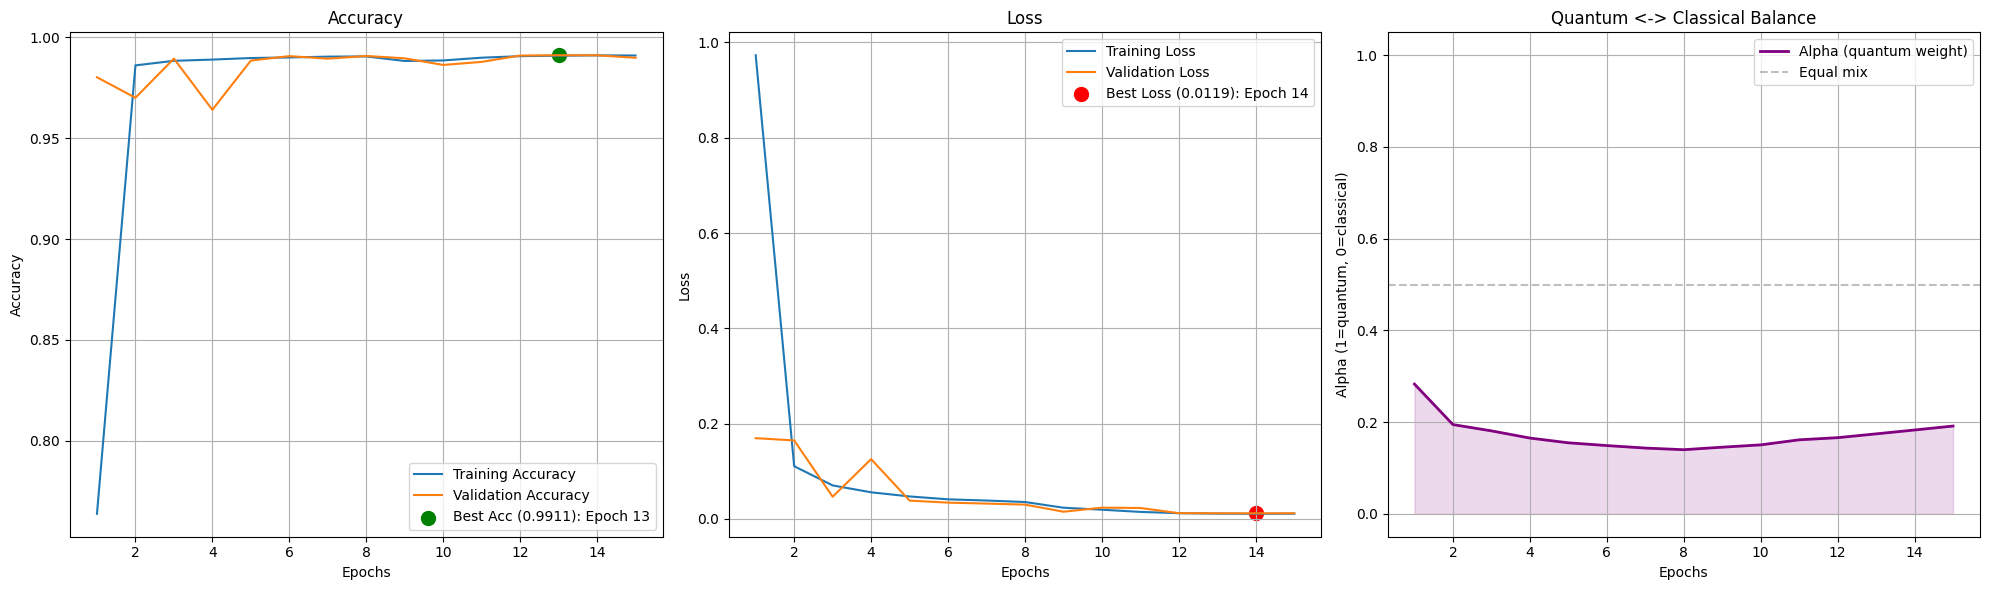

In [59]:
plot_learning_curves_qboostv1(history_qboostv1)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.90      0.96      0.93      4249
          06       0.94      0.11      0.20       401
          08       0.85      0.85      0.85      2748
          12       0.62      0.71      0.66      4633
          13       0.50      0.56      0.52      3429
          14       0.29      0.12      0.17      1139
          15       0.92      0.90      0.91      6421
          16       0.78      0.72      0.75      2061
          18       0.71      0.84      0.77      1058
          21       0.88      0.80      0.84      2899
          22       0.71      0.53      0.61       895
          23       0.86      0.88      0.87      2793
          27       0.84      0.91      0.88      1670
          30       0.96      0.83      0.89       803

    accuracy                           0.78     35199
   macro avg       0.77      0.70      0.70     35199
weighted avg       0.78      0.78      0.77     35

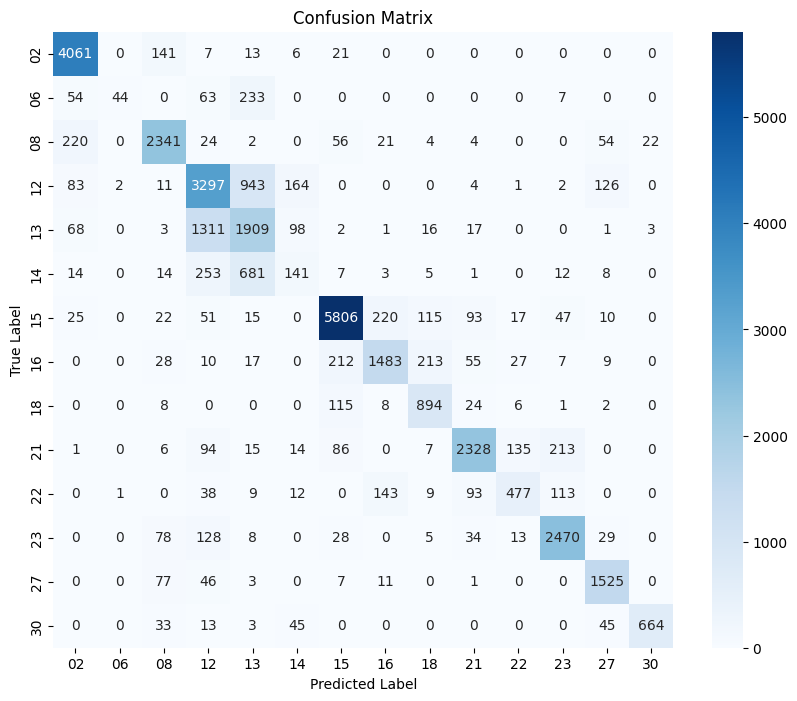

0.7795676013523112

In [60]:
evaluate_model(trained_model_qboostv1, test_loader, base_dataset.classes)

In [61]:
save_model(trained_model_qboostv1, model_path_qboostv1, model_name_qboostv1)

Saved model weights for QuantumBoostNetV1: QuantumBoostNetV1/QuantumBoostNetV1_Depolarizing.pth


## QuantumBoost (V2)

### Define Model

In [36]:
model_name_qboostv2 = "QuantumBoostNetV2"
(MODEL_DIR / model_name_qboostv2).mkdir(parents=True, exist_ok=True)
model_path_qboostv2 = f"{model_name_qboostv2}/{model_name_qboostv2}{NOISE_SUFFIX}.pth"

In [37]:
def make_qlayer_qboostv2():
    dev, nm = make_device_and_noise()
    
    @qml.qnode(dev, interface="torch")
    def quantum_circuit_qboostv2(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
        
    quantum_circuit_qboostv2 = wrap_with_noise(quantum_circuit_qboostv2, nm)

    weight_shapes_qboostv2 = {"weights": (N_LAYERS, N_QUBITS, 3)}
    
    qlayer_qboostv2 = qnn.TorchLayer(quantum_circuit_qboostv2, weight_shapes_qboostv2)

    return qlayer_qboostv2

In [38]:
class QuantumBoostNetV2(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNetV2, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, N_QUBITS)
        self.qlayer = make_qlayer_qboostv2()
        self.fc_q_out = nn.Linear(N_QUBITS, num_classes)

        # Classical Boost Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # Phase State
        self._phase = "Quantum"
        self._alpha = 1.0

        # Freeze Classical Head
        self._set_classical_head_grad(False)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
            
        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers

    def _set_classical_head_grad(self, requires_grad):
        for param in self.classical_head.parameters():
            param.requires_grad = requires_grad

    def _set_quantum_path_grad(self, requires_grad):
        self.fc_to_q.requires_grad_(requires_grad)
        for param in self.qlayer.parameters():
            param.requires_grad = requires_grad
        self.fc_q_out.requires_grad_(requires_grad)

    def enable_boost(self):
        if self._phase == "Boost":
            return
            
        self._phase = "Boost"
        self._alpha = 0.8

        # Freeze Quantum, Unfreeze Classical
        self._set_quantum_path_grad(False)
        self._set_classical_head_grad(True)
        
        print(f"   [QuantumBoostNetV2] Phase 2 (Boost) enabled:")
        print(f"      Quantum path: FROZEN (fixed residual)")
        print(f"      Classical head: UNFROZEN (training)")
        print(f"      Initial alpha: {self._alpha}")

    @property
    def alpha(self):
        return self._alpha

    @alpha.setter
    def alpha(self, value):
        self._alpha = max(0.0, min(1.0, value))

    @property
    def phase(self):
        return self._phase

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)
        
        if self._phase == "Quantum":
            q = self.fc_to_q(feat)      # (B, 10)
            q = torch.tanh(q) * math.pi # (B, 10)
            q = self.qlayer(q)          # (B, 10)
            logits = self.fc_q_out(q)   # (B, num_classes)
            
        else:
            with torch.no_grad():
                q = self.fc_to_q(feat)
                q = torch.tanh(q) * math.pi
                q = self.qlayer(q)
                q_logits = self.fc_q_out(q)      # (B, num_classes) — has gradients
                
            c_logits = self.classical_head(feat) # (B, num_classes) — no gradients
            
            logits = self._alpha * q_logits + (1 - self._alpha) * c_logits
            
        return logits

In [39]:
def train_model_qboostv2(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_quantum, num_epochs_boost, patience=2, alpha_start=0.8, alpha_end=0.2):
    total_epochs = num_epochs_quantum + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': [], 'phase': [], 'epoch_times': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    boost_start_epoch = num_epochs_quantum

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Quantum): {num_epochs_quantum} epochs")
    print(f"   Phase 2 (Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs (<0.2% improvement)")
    print(f"   Boost alpha: {alpha_start} → {alpha_end} (hard linear schedule)")

    total_start = time.time()

    for epoch in range(total_epochs):
        epoch_start = time.time()
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{model.phase.capitalize()}]  "
              f"(lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        history['phase'].append(model.phase)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if model.phase == "Quantum":
            if epoch >= 5:
                improvement = current_val_acc - prev_val_acc
                if improvement < 0.002:
                    plateau_counter += 1
                else:
                    plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_quantum:
                print(f"\n   >> Quantum phase complete ({num_epochs_quantum} epochs)")
                trigger_boost = True

            if trigger_boost:
                boost_start_epoch = epoch + 1
                model.enable_boost()

                # New Optimizer For The Newly Unfrozen Parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"      New optimizer for boost phase (lr=1e-3)")
                print()

        elif model.phase == "Boost":
            # Hard linear alpha anneal
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                model.alpha = alpha_start + progress * (alpha_end - alpha_start)

        epoch_elapsed = time.time() - epoch_start
        history['epoch_times'].append(epoch_elapsed)
        print(f"Epoch Time: {epoch_elapsed:.1f}s")
        print()

    total_elapsed = time.time() - total_start
    history['total_time'] = total_elapsed

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    print(f"Total Training Time: {total_elapsed:.1f}s ({total_elapsed/60:.1f}m)")
    print(f"Average Epoch Time:  {np.mean(history['epoch_times']):.1f}s")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [40]:
model_qboostv2 = QuantumBoostNetV2(num_classes=num_classes).to(DEVICE)

num_epochs_quantum_qboostv2 = 10
num_epochs_boost_qboostv2   = 5

criterion_qboostv2 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboostv2 = optim.Adam(filter(lambda p: p.requires_grad, model_qboostv2.parameters()), lr=1e-3)

In [41]:
trained_model_qboostv2, history_qboostv2 = train_model_qboostv2(model_name=model_name_qboostv2,
                                                                model=model_qboostv2,
                                                                criterion=criterion_qboostv2,
                                                                optimizer=optimizer_qboostv2,
                                                                train_loader=train_loader,
                                                                val_loader=val_loader,
                                                                num_epochs_quantum=num_epochs_quantum_qboostv2,
                                                                num_epochs_boost=num_epochs_boost_qboostv2,
                                                                patience=2,
                                                                alpha_start=0.8,
                                                                alpha_end=0.2)

Training QuantumBoostNetV2:
   Phase 1 (Quantum): 10 epochs
   Phase 2 (Boost): 5 epochs
   Plateau patience: 2 epochs (<0.2% improvement)
   Boost alpha: 0.8 → 0.2 (hard linear schedule)
Epoch 1/15  [Quantum]  (lr=0.001000, alpha=1.0000):
   train Loss: 2.2356  Acc: 0.1638
   val   Loss: 2.1800  Acc: 0.2391
Epoch Time: 202.0s

Epoch 2/15  [Quantum]  (lr=0.000989, alpha=1.0000):
   train Loss: 1.2793  Acc: 0.3803
   val   Loss: 1.3349  Acc: 0.3954
Epoch Time: 202.1s

Epoch 3/15  [Quantum]  (lr=0.000957, alpha=1.0000):
   train Loss: 1.2251  Acc: 0.4401
   val   Loss: 1.0591  Acc: 0.5326
Epoch Time: 201.6s

Epoch 4/15  [Quantum]  (lr=0.000905, alpha=1.0000):
   train Loss: 0.8704  Acc: 0.6083
   val   Loss: 0.7080  Acc: 0.6261
Epoch Time: 202.0s

Epoch 5/15  [Quantum]  (lr=0.000835, alpha=1.0000):
   train Loss: 0.5307  Acc: 0.8393
   val   Loss: 0.3617  Acc: 0.9675
Epoch Time: 201.9s

Epoch 6/15  [Quantum]  (lr=0.000750, alpha=1.0000):
   train Loss: 0.2644  Acc: 0.9789
   val   Loss: 

In [42]:
def plot_learning_curves_qboostv2(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    phase_hist = history['phase']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    # Find phase transition point
    boost_start = None
    for i, p in enumerate(phase_hist):
        if p == "Boost":
            boost_start = i + 1 # 1-indexed
            break

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    if boost_start:
        axes[0].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    if boost_start:
        axes[1].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha + Phase
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    if boost_start:
        axes[2].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[2].legend(loc='upper right')
    axes[2].set_title('Quantum <-> Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

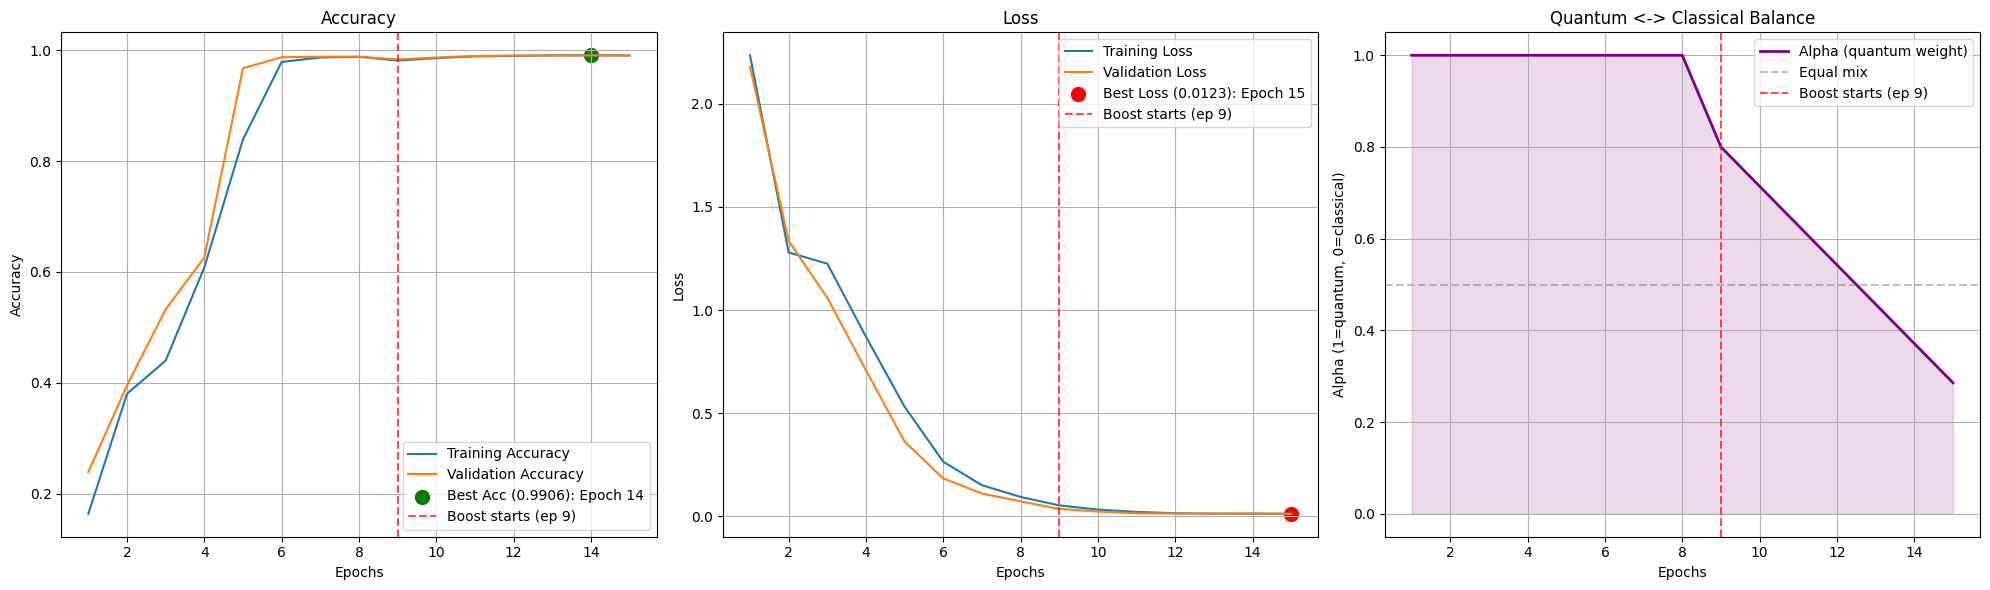

In [43]:
plot_learning_curves_qboostv2(history_qboostv2)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.92      0.92      0.92      4249
          06       0.78      0.13      0.22       401
          08       0.79      0.84      0.81      2748
          12       0.54      0.76      0.63      4633
          13       0.51      0.41      0.45      3429
          14       0.22      0.07      0.11      1139
          15       0.88      0.85      0.87      6421
          16       0.79      0.78      0.79      2061
          18       0.74      0.57      0.64      1058
          21       0.81      0.78      0.80      2899
          22       0.59      0.61      0.60       895
          23       0.91      0.88      0.90      2793
          27       0.86      0.96      0.91      1670
          30       0.88      0.93      0.90       803

    accuracy                           0.76     35199
   macro avg       0.73      0.68      0.68     35199
weighted avg       0.75      0.76      0.75     35

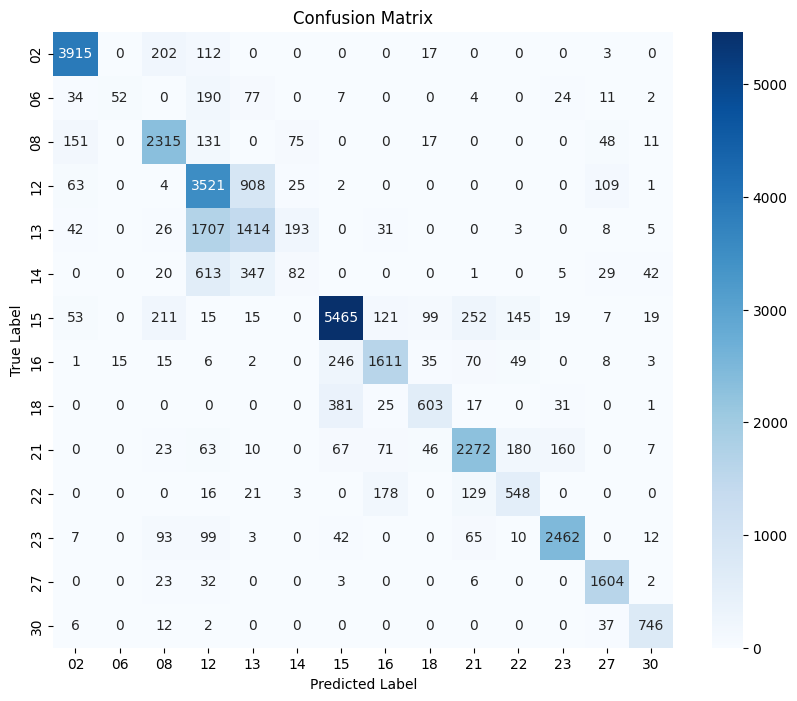

0.7559873860052843

In [44]:
evaluate_model(trained_model_qboostv2, test_loader, base_dataset.classes)

In [45]:
save_model(trained_model_qboostv2, model_path_qboostv2, model_name_qboostv2)

Saved model weights for QuantumBoostNetV2: QuantumBoostNetV2/QuantumBoostNetV2_Depolarizing.pth


## QuantumBoost (V3)

### Define Model

In [46]:
model_name_qboostv3 = "QuantumBoostNetV3"
(MODEL_DIR / model_name_qboostv3).mkdir(parents=True, exist_ok=True)
model_path_qboostv3 = f"{model_name_qboostv3}/{model_name_qboostv3}{NOISE_SUFFIX}.pth"

In [47]:
def make_qlayer_qboostv3():
    dev, nm = make_device_and_noise()
    
    @qml.qnode(dev, interface="torch")
    def quantum_circuit_qboostv3(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
        
        qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
        
    quantum_circuit_qboostv3 = wrap_with_noise(quantum_circuit_qboostv3, nm)

    weight_shapes_qboostv3 = {"weights": (N_LAYERS, N_QUBITS, 3)}
    
    qlayer_qboostv3 = qnn.TorchLayer(quantum_circuit_qboostv3, weight_shapes_qboostv3)

    return qlayer_qboostv3

In [48]:
class QuantumBoostNetV3(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNetV3, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, N_QUBITS)
        self.qlayer = make_qlayer_qboostv3()
        self.fc_q_out = nn.Linear(N_QUBITS, num_classes)

        # Classical Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # Learnable Mixing Gate
        self.gate = nn.Parameter(torch.tensor(-3.0))

        # Freeze Quantum Head Initially
        self._freeze_quantum_path()
        self._boost_enabled = False

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
            
        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers
    
    def _freeze_quantum_path(self):
        self.fc_to_q.requires_grad_(False)
        for param in self.qlayer.parameters():
            param.requires_grad = False
        self.fc_q_out.requires_grad_(False)

    def _unfreeze_quantum_path(self):
        self.fc_to_q.requires_grad_(True)
        for param in self.qlayer.parameters():
            param.requires_grad = True
        self.fc_q_out.requires_grad_(True)

    def _freeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = False

    def enable_boost(self):
        if self._boost_enabled:
            return
        self._boost_enabled = True

        # Freeze Classical, Unfreeze Quantum
        self._freeze_classical_head()
        self._unfreeze_quantum_path()
        
        print("   [QuantumBoostNetV3] Boost enabled: quantum path unfrozen, classical head frozen.")

    def set_alpha(self, target_alpha):
        target_alpha = max(0.01, min(0.99, target_alpha))
        self.gate.data = torch.tensor(
            math.log(target_alpha / (1 - target_alpha)),
            device=self.gate.device
        )

    @property
    def alpha(self):
        return torch.sigmoid(self.gate).item()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)

        # Quantum Path
        q = self.fc_to_q(feat)       # (B, 10)
        q = torch.tanh(q) * math.pi  # (B, 10) scaled to [-pi, pi]
        q = self.qlayer(q)           # (B, 10)
        q = self.fc_q_out(q)         # (B, num_classes)

        # Classical Path
        c = self.classical_head(feat) # (B, num_classes)

        # Gated Fusion
        alpha = torch.sigmoid(self.gate)     # scalar in (0, 1)
        logits = alpha * q + (1 - alpha) * c # (B, num_classes)
        return logits

In [49]:
def train_model_qboostv3(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_classical, num_epochs_boost, patience=2):
    total_epochs = num_epochs_classical + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': [], 'epoch_times': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    phase_label = "Classical"
    boost_start_epoch = num_epochs_classical
    alpha_at_boost_start = None

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Classical): {num_epochs_classical} epochs; Phase 2 (Quantum Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs; Boost alpha target: 0.8")
    print(f"   Initial alpha: {model.alpha:.4f}")
    print(f"   LR schedule: CosineAnnealing over {total_epochs} total epochs")

    total_start = time.time()

    for epoch in range(total_epochs):
        epoch_start = time.time()
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{phase_label}]  (lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if phase_label == "Classical":
            if epoch >= 5:
                improvement = current_val_acc - prev_val_acc
                if improvement < 0.002:
                    plateau_counter += 1
                else:
                    plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_classical:
                print(f"\n   >> Classical phase complete ({num_epochs_classical} epochs)")
                trigger_boost = True

            if trigger_boost:
                phase_label = "Quantum Boost"
                boost_start_epoch = epoch + 1
                alpha_at_boost_start = model.alpha
                model.enable_boost()

                # New optimizer for the newly unfrozen quantum parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"   >> New optimizer for quantum boost phase (lr=1e-3)")
                print()

        elif phase_label == "Quantum Boost":
            # Anneal alpha linearly toward 0.8 (quantum-dominant)
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                target_alpha = alpha_at_boost_start + progress * (0.8 - alpha_at_boost_start)
                model.set_alpha(target_alpha)

        epoch_elapsed = time.time() - epoch_start
        history['epoch_times'].append(epoch_elapsed)
        print(f"Epoch Time: {epoch_elapsed:.1f}s")
        print()

    total_elapsed = time.time() - total_start
    history['total_time'] = total_elapsed

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    print(f"Total Training Time: {total_elapsed:.1f}s ({total_elapsed/60:.1f}m)")
    print(f"Average Epoch Time:  {np.mean(history['epoch_times']):.1f}s")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [50]:
model_qboostv3 = QuantumBoostNetV3(num_classes=num_classes).to(DEVICE)

num_epochs_classical_qboostv3 = 10
num_epochs_boost_qboostv3     = 5

criterion_qboostv3 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboostv3 = optim.Adam(filter(lambda p: p.requires_grad, model_qboostv3.parameters()), lr=1e-3)

In [51]:
trained_model_qboostv3, history_qboostv3 = train_model_qboostv3(model_name=model_name_qboostv3,
                                                                model=model_qboostv3,
                                                                criterion=criterion_qboostv3,
                                                                optimizer=optimizer_qboostv3,
                                                                train_loader=train_loader,
                                                                val_loader=val_loader,
                                                                num_epochs_classical=num_epochs_classical_qboostv3,
                                                                num_epochs_boost=num_epochs_boost_qboostv3,
                                                                patience=2)

Training QuantumBoostNetV3:
   Phase 1 (Classical): 10 epochs; Phase 2 (Quantum Boost): 5 epochs
   Plateau patience: 2 epochs; Boost alpha target: 0.8
   Initial alpha: 0.0474
   LR schedule: CosineAnnealing over 15 total epochs
Epoch 1/15  [Classical]  (lr=0.001000, alpha=0.0474):
   train Loss: 0.2951  Acc: 0.8908
   val   Loss: 0.1156  Acc: 0.9554
Epoch Time: 176.3s

Epoch 2/15  [Classical]  (lr=0.000989, alpha=0.0186):
   train Loss: 0.0584  Acc: 0.9757
   val   Loss: 0.0397  Acc: 0.9830
Epoch Time: 175.6s

Epoch 3/15  [Classical]  (lr=0.000957, alpha=0.0156):
   train Loss: 0.0379  Acc: 0.9821
   val   Loss: 0.0261  Acc: 0.9868
Epoch Time: 176.1s

Epoch 4/15  [Classical]  (lr=0.000905, alpha=0.0175):
   train Loss: 0.0279  Acc: 0.9859
   val   Loss: 0.0300  Acc: 0.9857
Epoch Time: 175.7s

Epoch 5/15  [Classical]  (lr=0.000835, alpha=0.0190):
   train Loss: 0.0227  Acc: 0.9874
   val   Loss: 0.0729  Acc: 0.9711
Epoch Time: 175.4s

Epoch 6/15  [Classical]  (lr=0.000750, alpha=0.021

In [52]:
def plot_learning_curves_qboostv3(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha (Quantum vs Classical mix)
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    axes[2].legend(loc='lower right')
    axes[2].set_title('Quantum <-> Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

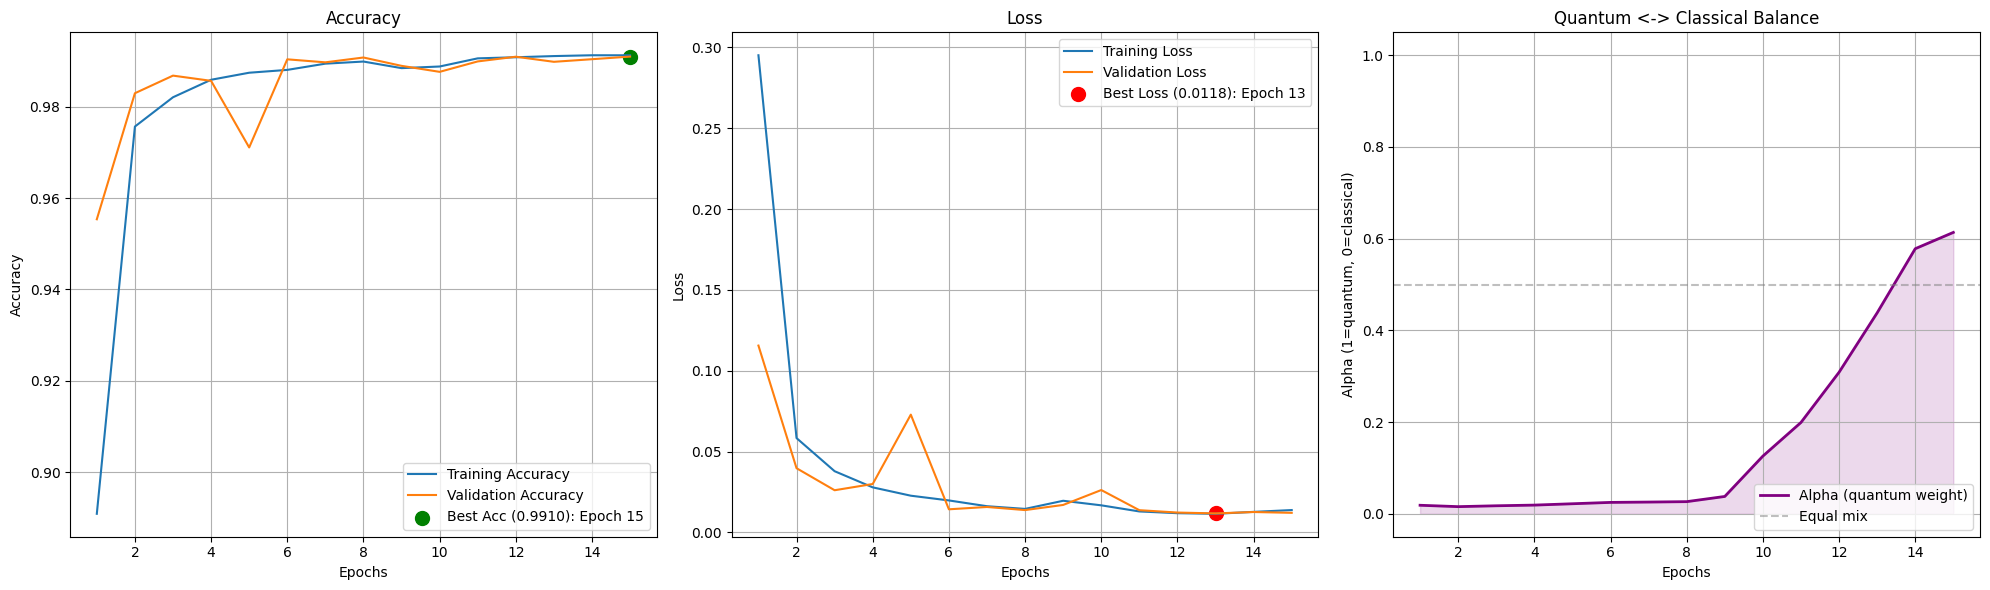

In [53]:
plot_learning_curves_qboostv3(history_qboostv3)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.91      0.96      0.93      4249
          06       0.99      0.33      0.49       401
          08       0.83      0.86      0.84      2748
          12       0.65      0.62      0.64      4633
          13       0.47      0.61      0.53      3429
          14       0.19      0.05      0.08      1139
          15       0.87      0.92      0.89      6421
          16       0.71      0.65      0.68      2061
          18       0.59      0.78      0.67      1058
          21       0.87      0.79      0.83      2899
          22       0.83      0.57      0.68       895
          23       0.88      0.89      0.88      2793
          27       0.95      0.95      0.95      1670
          30       0.96      0.85      0.90       803

    accuracy                           0.77     35199
   macro avg       0.77      0.70      0.72     35199
weighted avg       0.77      0.77      0.77     35

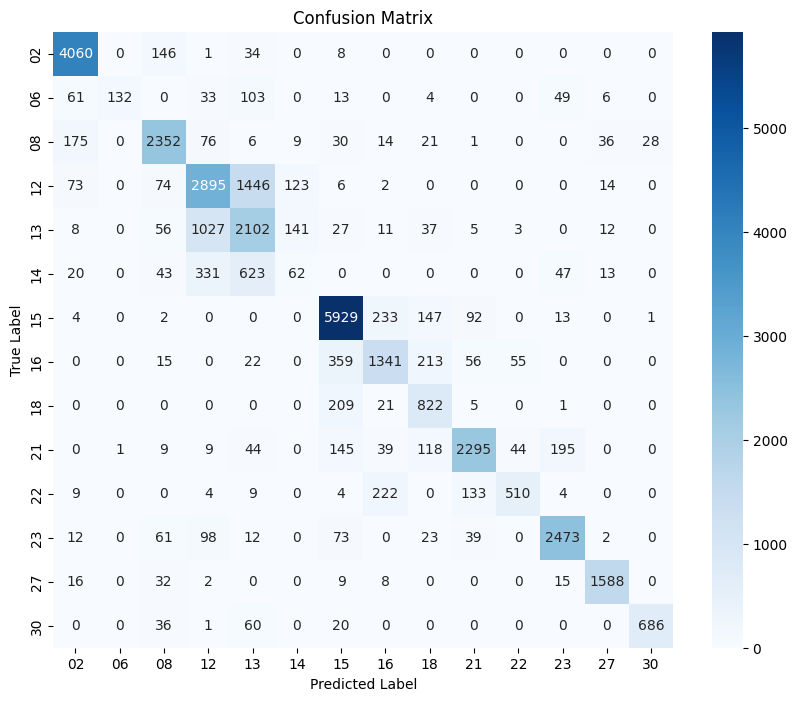

0.7740844910366772

In [54]:
evaluate_model(trained_model_qboostv3, test_loader, base_dataset.classes)

In [55]:
save_model(trained_model_qboostv3, model_path_qboostv3, model_name_qboostv3)

Saved model weights for QuantumBoostNetV3: QuantumBoostNetV3/QuantumBoostNetV3_Depolarizing.pth
